# Clustering analysis

Explore the 17-feature daily dataset, then work through the five models in your MIT practice notebook: **K-means, K-medoids, agglomerative clustering, Gaussian mixtures and DBSCAN**. Fit each baseline, inspect its profiles and metrics, then tune the models, compare calibrations and finish with a comprehensive score table.

Run all cells with the repository's `.venv` kernel. Run `01_daily_macro_dataset.ipynb` to refresh the local data. Your MIT `practice.ipynb` is a read-only reference; this notebook uses the market dataset.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


## Load and preview

Load the version that preserves all equity trading dates and missing macro observations. No filling or scaling is applied.


In [2]:
df = pd.read_csv("data/daily_macro_levels.csv", index_col="date", parse_dates=["date"])
df.head()


,sp500,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio,sp500_momentum_63d,sp500_drawdown_252d,sp500_realized_vol_21d,sp500_volatility_expansion_21_126d,sp500_trend_efficiency_21d,sp500_rsi_14d,sp500_ma_gap_200d,sp500_atrp_14d
date,,,,,,,,,,,,,,,,,
2011-10-05,1144.030029,1.80,0.12,1.67,3.36,37.81,38.31,-0.50,0.697452,-0.167930,-0.161028,30.526915,0.161725,0.051786,45.885661,-0.105030,2.877053
2011-10-06,1164.969971,1.88,0.13,1.72,3.34,36.27,37.04,-0.77,0.705230,-0.142806,-0.145672,29.545574,0.123565,0.082629,49.861520,-0.088329,2.811149
2011-10-07,1155.459961,1.94,0.16,1.80,3.32,36.20,37.31,-1.11,0.706920,-0.132747,-0.152646,29.463775,0.120178,0.076001,48.131934,-0.095405,2.762521
2011-10-10,1194.890015,NaN,NaN,NaN,NaN,33.02,34.79,-1.77,0.715674,-0.094748,-0.123730,30.204664,0.127905,0.099304,55.088089,-0.064309,2.716376
2011-10-11,1195.540039,1.95,0.23,1.86,3.32,32.86,34.06,-1.20,0.720335,-0.097305,-0.123254,30.147511,0.126685,0.082466,55.194769,-0.063573,2.592314


In [3]:
df.isnull().sum()

sp500                                  0
breakeven_10y                         28
real_yield_10y                        28
slope_10y_2y                          28
baa_10y_spread                        30
vix                                    0
vix3m                                  0
vix_term_spread                        0
sp500_gold_ratio                       3
sp500_momentum_63d                     0
sp500_drawdown_252d                    0
sp500_realized_vol_21d                 0
sp500_volatility_expansion_21_126d     0
sp500_trend_efficiency_21d             0
sp500_rsi_14d                          0
sp500_ma_gap_200d                      0
sp500_atrp_14d                         0
dtype: int64

## S&P 500 log returns

Calculate daily S&P 500 log returns from the index close on `df` **before** dropping incomplete rows, preserving equity trading-day intervals. Macro levels, the precomputed S&P 500/gold ratio and all eight technical descriptors retain their builder values; the technical indicators are not differenced or transformed a second time.

Every feature then passes through the same `StandardScaler` before PCA, t-SNE and clustering. Gold closes remain a source input in `01` and are excluded from clustering.


In [4]:
df_transformed = df.copy()
df_transformed["sp500"] = np.log(df["sp500"]).diff()
df_transformed = df_transformed.rename(columns={"sp500": "sp500_log_return"}).dropna()
df_transformed.head()


,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio,sp500_momentum_63d,sp500_drawdown_252d,sp500_realized_vol_21d,sp500_volatility_expansion_21_126d,sp500_trend_efficiency_21d,sp500_rsi_14d,sp500_ma_gap_200d,sp500_atrp_14d
date,,,,,,,,,,,,,,,,,
2011-10-06,0.018138,1.88,0.13,1.72,3.34,36.27,37.04,-0.77,0.705230,-0.142806,-0.145672,29.545574,0.123565,0.082629,49.861520,-0.088329,2.811149
2011-10-07,-0.008197,1.94,0.16,1.80,3.32,36.20,37.31,-1.11,0.706920,-0.132747,-0.152646,29.463775,0.120178,0.076001,48.131934,-0.095405,2.762521
2011-10-11,0.000544,1.95,0.23,1.86,3.32,32.86,34.06,-1.20,0.720335,-0.097305,-0.123254,30.147511,0.126685,0.082466,55.194769,-0.063573,2.592314
2011-10-12,0.009747,1.98,0.26,1.95,3.33,31.26,32.97,-1.71,0.718046,-0.080819,-0.114666,30.168926,0.125858,0.084255,57.168540,-0.054211,2.530000
2011-10-13,-0.002978,1.92,0.27,1.90,3.29,30.70,32.71,-2.01,0.721922,-0.089336,-0.117299,29.892937,0.116602,0.037665,56.348993,-0.056816,2.456463


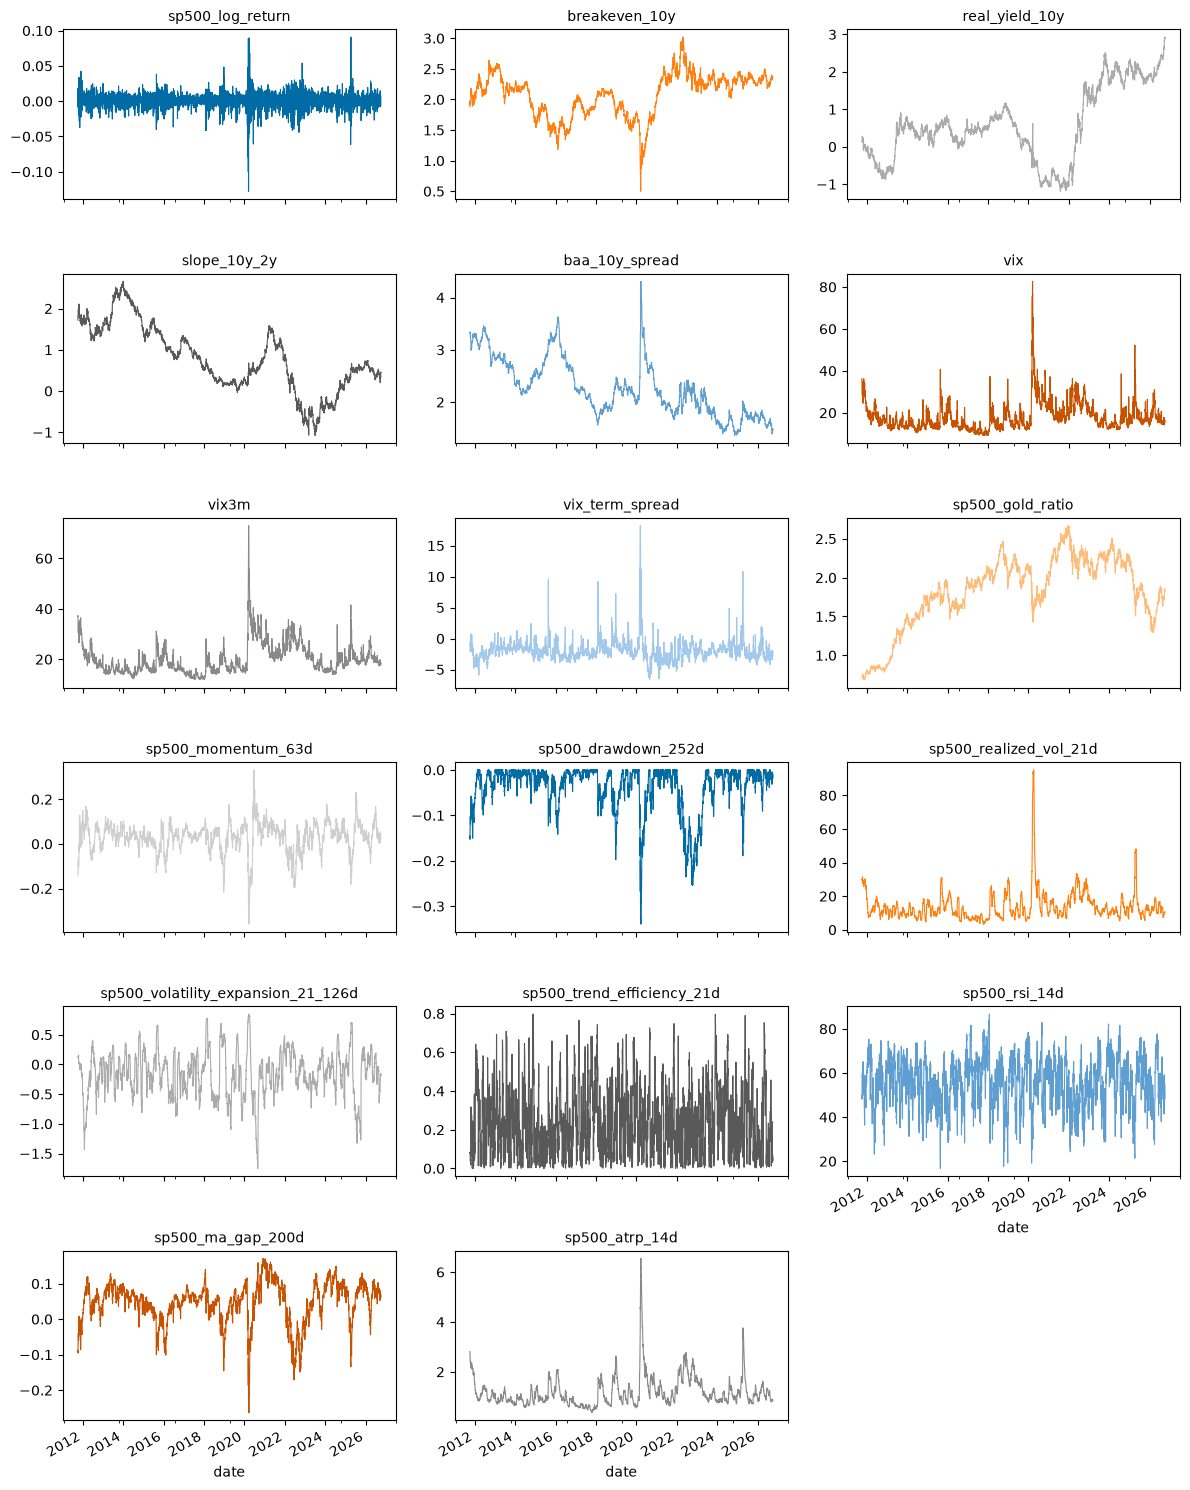

In [5]:
plot_rows = (len(df_transformed.columns) + 2) // 3
with plt.style.context("tableau-colorblind10"):
    axes = df_transformed.plot(subplots=True, layout=(plot_rows, 3), figsize=(12, 2.5 * plot_rows),
                               sharex=True, legend=False, linewidth=0.8)
    for ax, column in zip(axes.flat, df_transformed.columns):
        ax.set_title(column, fontsize=10)
    for ax in axes.flat[len(df_transformed.columns):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

## Feature distributions

Histogram with KDE and a horizontal boxplot for each clustering input, in its current units. Follow the layout from your MIT `Data_Analysis_and_Vis/practice.ipynb`: boxplot above histogram, shared x-axis, **red dashed = mean**, **blue solid = median**.


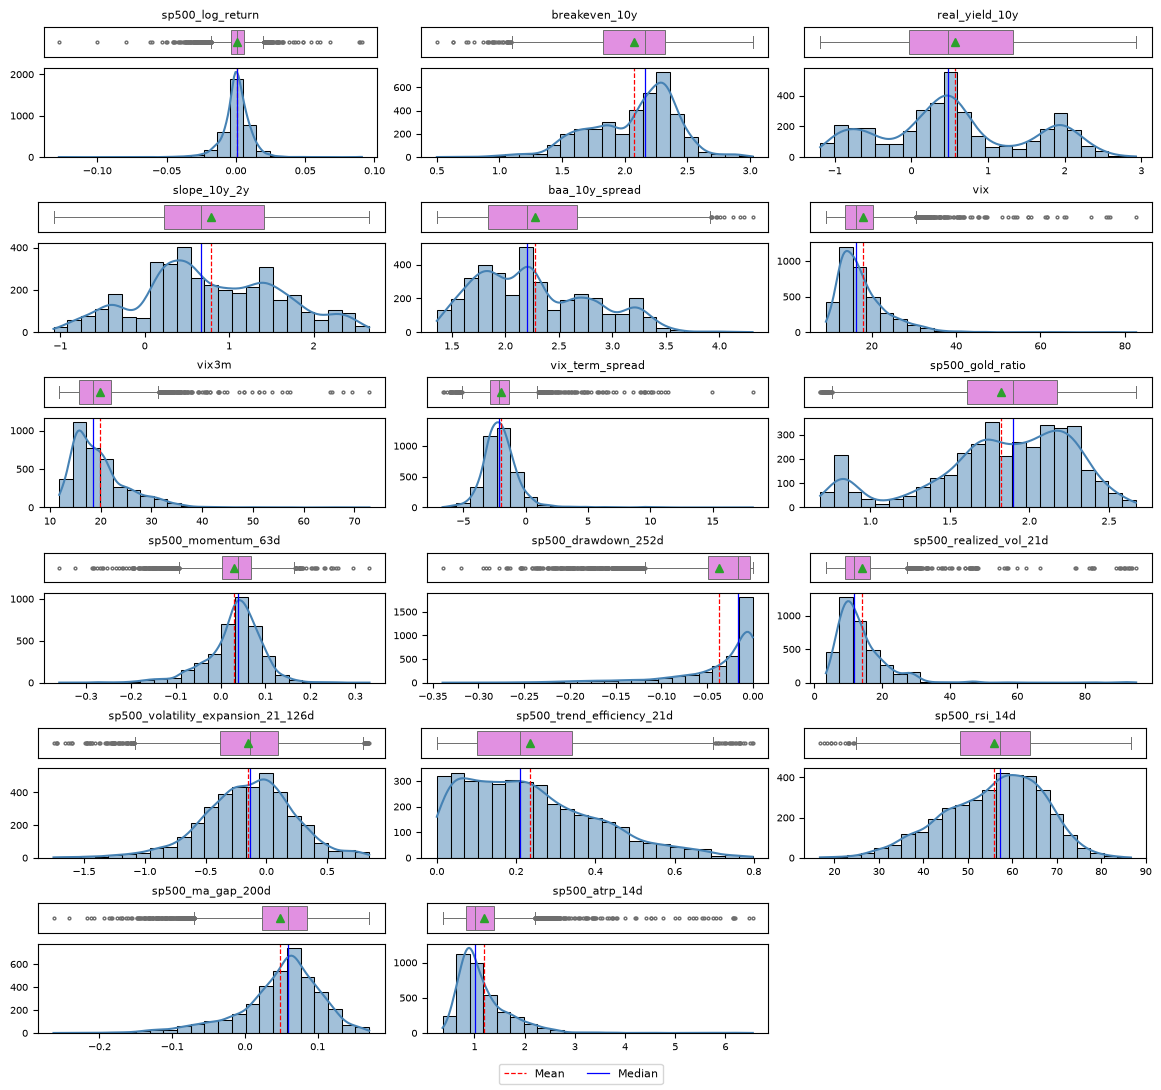

In [6]:
columns = df_transformed.columns
nrows = (len(columns) + 2) // 3
fig = plt.figure(figsize=(11.5, 1.8 * nrows), layout="constrained")
grid = fig.add_gridspec(nrows, 3)

for i, column in enumerate(columns):
    pair = grid[i // 3, i % 3].subgridspec(2, 1, height_ratios=[1, 3])
    ax_box = fig.add_subplot(pair[0])
    ax_hist = fig.add_subplot(pair[1], sharex=ax_box)
    values = df_transformed[column]

    sns.boxplot(x=values, showmeans=True, color="violet", fliersize=2,
                linewidth=0.7, ax=ax_box)
    sns.histplot(x=values, bins=23, kde=True, color="steelblue", ax=ax_hist)
    ax_hist.axvline(values.mean(), color="red", linestyle="--", linewidth=0.9, label="Mean")
    ax_hist.axvline(values.median(), color="blue", linewidth=0.9, label="Median")

    ax_box.set(xlabel="", ylabel="", yticks=[])
    ax_box.set_title(column, fontsize=8)
    ax_box.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_hist.set(xlabel="", ylabel="")
    ax_hist.tick_params(labelsize=7)

fig.legend(*ax_hist.get_legend_handles_labels(), loc="outside lower center", ncol=2, fontsize=8)
plt.show()


## Clustering inputs

Replace only the S&P 500 index level with its daily log return. All 17 features pass through `StandardScaler`. Dates remain row indexes and never enter clustering. PCA and t-SNE provide visualizations; scores always use the original standardized feature space.

The four fixed-count models start with **three clusters** for comparison. DBSCAN chooses its own cluster count. Later sections vary model parameters and scaling/dimension choices. This is a full-sample descriptive analysis.


## Conventional partitioning

A 25th/75th-percentile split places each feature into low, middle and high bands. With 17 features, that permits **3^17 = 129,140,163** joint combinations, many sparsely observed. K-means provides a smaller set of joint profiles instead. The panels below show the individual percentile bands for comparison.


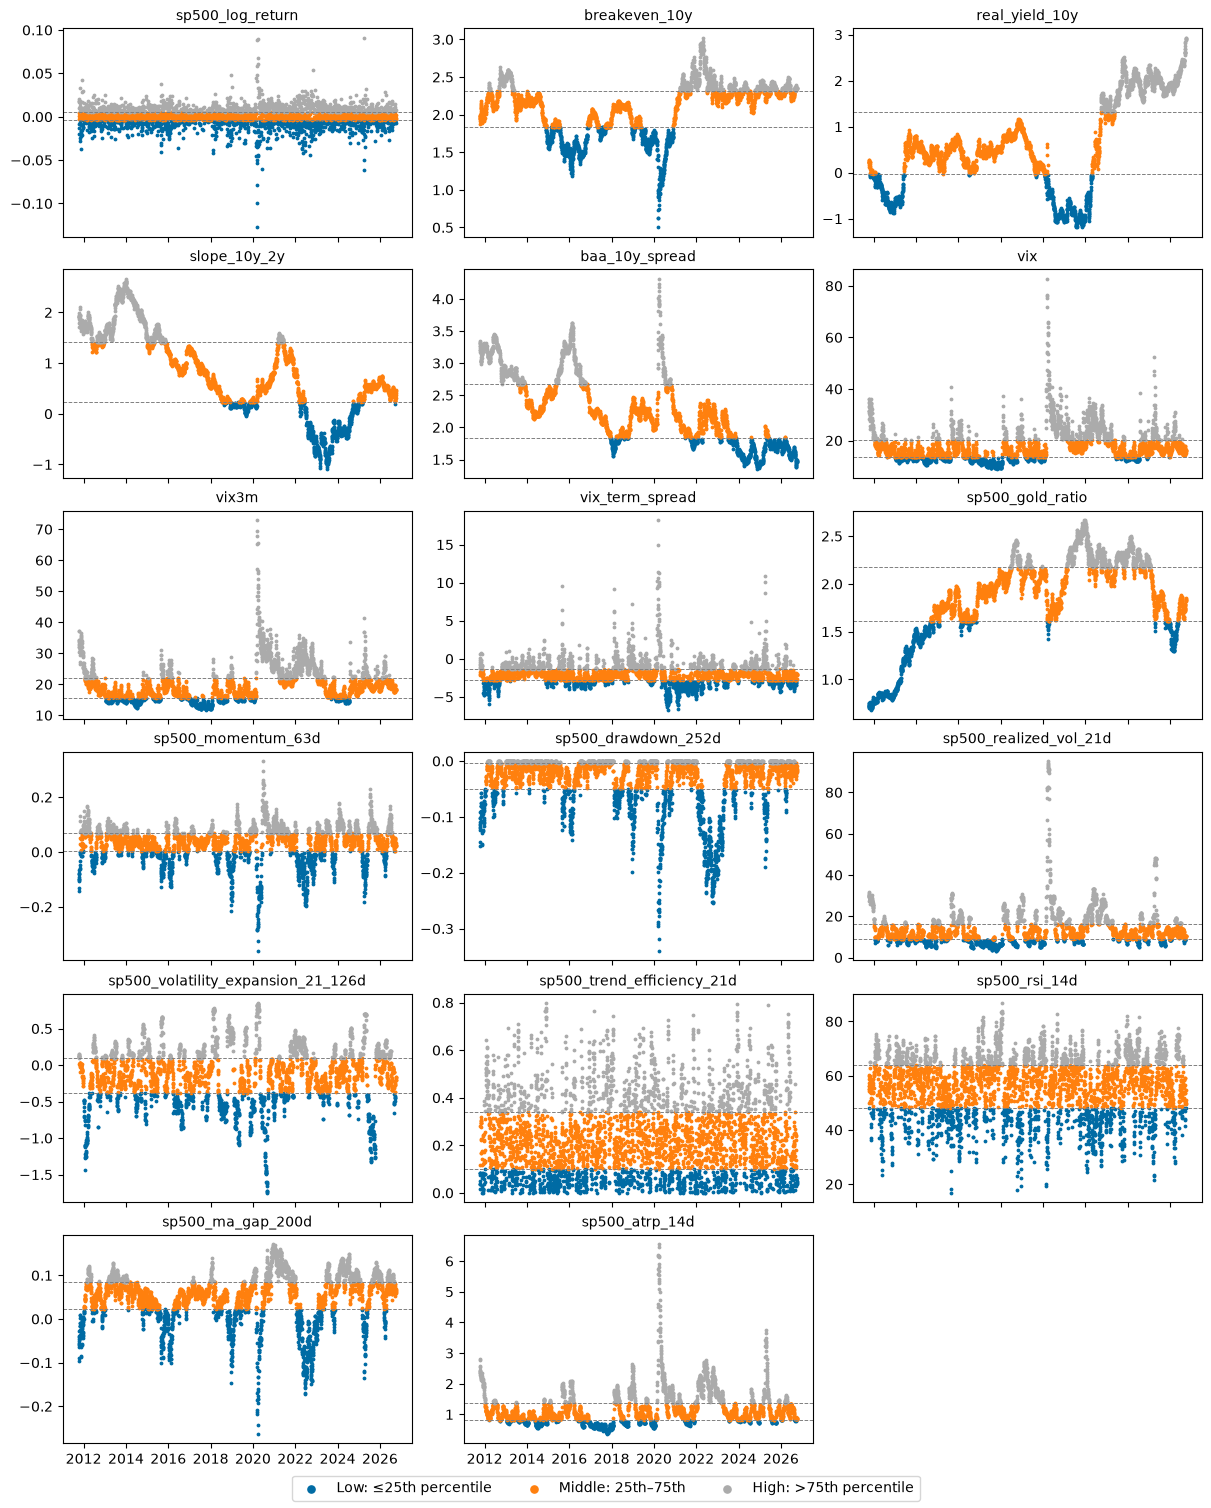

In [7]:
plot_rows = (len(df_transformed.columns) + 2) // 3
with plt.style.context("tableau-colorblind10"):
    fig, axes = plt.subplots(plot_rows, 3, figsize=(12, 2.5 * plot_rows), sharex=True, layout="constrained")
    for ax, column in zip(axes.flat, df_transformed.columns):
        series = df_transformed[column]
        q25, q75 = series.quantile([0.25, 0.75])
        partitions = {
            "Low: ≤25th percentile": series <= q25,
            "Middle: 25th–75th": (series > q25) & (series <= q75),
            "High: >75th percentile": series > q75,
        }
        for label, mask in partitions.items():
            ax.scatter(series.index[mask], series[mask], s=3, label=label)
        for threshold in [q25, q75]:
            ax.axhline(threshold, color="grey", linestyle="--", linewidth=0.7)
        ax.set_title(column, fontsize=10)

    for ax in axes.flat[len(df_transformed.columns):]:
        ax.set_visible(False)
    fig.legend(*axes.flat[0].get_legend_handles_labels(),
               loc="outside lower center", ncol=3, markerscale=3)
    plt.show()

## EDA

In [8]:
df_transformed.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
sp500_log_return,3738.0,0.000496,0.010610,-0.127652,-0.003764,0.000671,0.005640,0.090895
breakeven_10y,3738.0,2.073093,0.348344,0.500000,1.830000,2.160000,2.320000,3.020000
real_yield_10y,3738.0,0.571683,0.960495,-1.190000,-0.027500,0.480000,1.320000,2.930000
slope_10y_2y,3738.0,0.781870,0.808628,-1.080000,0.230000,0.670000,1.410000,2.660000
baa_10y_spread,3738.0,2.274955,0.540683,1.360000,1.840000,2.200000,2.670000,4.310000
vix,3738.0,17.911715,6.588350,9.140000,13.590000,16.270000,20.337500,82.690000
vix3m,3738.0,19.870626,5.892105,11.850000,15.700000,18.480000,22.010000,72.980000
vix_term_spread,3738.0,-1.958911,1.658359,-6.660000,-2.840000,-2.110000,-1.310000,18.230000
sp500_gold_ratio,3738.0,1.823214,0.456171,0.685139,1.606641,1.894439,2.172356,2.669226
sp500_momentum_63d,3738.0,0.030843,0.063185,-0.359513,0.004055,0.038820,0.068864,0.331832


In [9]:
from sklearn.preprocessing import StandardScaler
# Scaling the data before clustering
scaler = StandardScaler()
subset = df_transformed.copy()
subset_scaled = scaler.fit_transform(subset)

In [10]:
subset_scaled_df = pd.DataFrame(
    subset_scaled, columns=subset.columns, index=subset.index
)

In [11]:
subset_scaled_df.head()

,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio,sp500_momentum_63d,sp500_drawdown_252d,sp500_realized_vol_21d,sp500_volatility_expansion_21_126d,sp500_trend_efficiency_21d,sp500_rsi_14d,sp500_ma_gap_200d,sp500_atrp_14d
date,,,,,,,,,,,,,,,,,
2011-10-06,1.663041,-0.554390,-0.459911,1.160306,1.970079,2.786850,2.914352,0.717016,-2.451125,-2.748638,-2.141044,1.747688,0.724574,-0.926562,-0.539542,-2.383040,2.693337
2011-10-07,-0.819426,-0.382123,-0.428673,1.259253,1.933083,2.776223,2.960183,0.511967,-2.447422,-2.589411,-2.278630,1.738474,0.715631,-0.966644,-0.695655,-2.506508,2.612811
2011-10-11,0.004513,-0.353412,-0.355784,1.333462,1.933083,2.269200,2.408523,0.457689,-2.418009,-2.028412,-1.698772,1.815488,0.732809,-0.927547,-0.058161,-1.951099,2.330953
2011-10-12,0.872052,-0.267279,-0.324546,1.444777,1.951581,2.026315,2.223505,0.150115,-2.423028,-1.767462,-1.529359,1.817900,0.730626,-0.916733,0.119993,-1.787753,2.227763
2011-10-13,-0.327485,-0.439545,-0.314133,1.382935,1.877591,1.941305,2.179372,-0.030811,-2.414530,-1.902278,-1.581296,1.786813,0.706191,-1.198465,0.046020,-1.833207,2.105989


In [12]:
from sklearn.decomposition import PCA

# Retain all components; this rotates rather than reduces the feature space.
n = subset.shape[1]
pca = PCA(n_components=n, random_state=1)
data_pca = pd.DataFrame(
    pca.fit_transform(subset_scaled_df),
    index=subset_scaled_df.index,
    columns=[f"PC{j + 1}" for j in range(n)],
)
exp_var = pca.explained_variance_ratio_
pd.DataFrame({
    "explained_variance": exp_var,
    "cumulative_variance": np.cumsum(exp_var),
}, index=data_pca.columns)


,explained_variance,cumulative_variance
PC1,0.385691,0.385691
PC2,0.160112,0.545804
PC3,0.092276,0.638080
PC4,0.069636,0.707716
PC5,0.062293,0.770008
PC6,0.055921,0.825929
PC7,0.045202,0.871131
PC8,0.039150,0.910280
PC9,0.029810,0.940091
PC10,0.016685,0.956776


## t-SNE visualization

Embed the standardized features in two dimensions. Dates are only the index. Use t-SNE to inspect local neighborhoods, not to fit models or calculate scores. The model sections color this same embedding by each model's labels; distant gaps and relative group sizes are not evidence of separation in the original space.


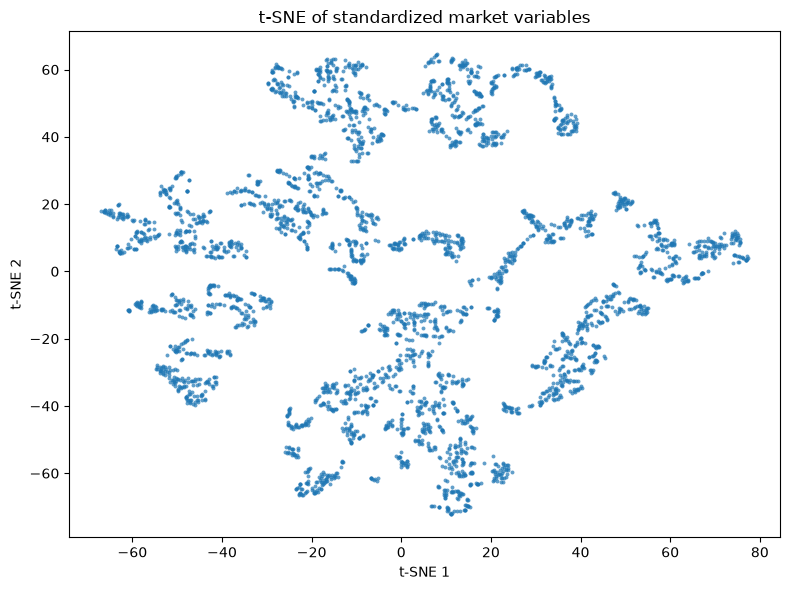

In [13]:
from sklearn.manifold import TSNE

# Fixed seed and PCA initialization make repeated runs reproducible.
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=1,
)
tsne_df = pd.DataFrame(
    tsne.fit_transform(subset_scaled_df),
    columns=["TSNE1", "TSNE2"],
    index=subset_scaled_df.index,
)

with plt.style.context("tableau-colorblind10"):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        tsne_df["TSNE1"], tsne_df["TSNE2"],
        color="tab:blue", s=8, alpha=0.7, linewidths=0,
    )
    ax.set(xlabel="t-SNE 1", ylabel="t-SNE 2",
           title="t-SNE of standardized market variables")
    plt.tight_layout()
    plt.show()


## Comparing the models

Keep the evaluation consistent: **silhouette ↑**, **Calinski–Harabasz ↑**, and **Davies–Bouldin ↓** are calculated on all 17 standardized features. Also report cluster sizes, coverage, the largest cluster's share of assigned observations, and fitting time. These geometric scores favor compact clusters; they do not measure investment performance.

For DBSCAN, label `-1` means noise. Exclude noise from geometric scores and report its count and coverage. A one-cluster or all-noise solution has undefined scores, shown as missing values. DBSCAN's scores use fewer observations, so read them together with coverage and cluster sizes.

The exact VIX/VIX3M/spread dependence creates one zero-variance PCA direction. Fit the baselines on the **16 informative components**, preserving all standardized Euclidean distances while avoiding a singular GMM covariance. The score space still contains all 17 features. Fitting times exclude preprocessing, shared distances, scoring and plots.

References: [scikit-learn clustering metrics](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation), [GMM model selection](https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_selection.html). Two reusable functions below keep the metric and visual comparisons consistent.


In [14]:
from time import perf_counter
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, cophenet, dendrogram
from kmedoids import KMedoids

CLUSTERING_DIR = Path("data") / "clustering"
CLUSTERING_DIR.mkdir(parents=True, exist_ok=True)
Z_eval = subset_scaled_df.to_numpy()
informative_components = np.linalg.matrix_rank(Z_eval)
X = data_pca.iloc[:, :informative_components].to_numpy()
D_eval = squareform(pdist(Z_eval))
D_fit = D_eval  # Full informative PCA preserves these Euclidean distances.
print(f"{len(X):,} observations, {Z_eval.shape[1]} features, {X.shape[1]} informative PCs")
baseline_rows, baseline_labels, BASELINE_PARAMS = [], {}, {}


def cluster_metrics(name, labels, elapsed):
    assigned = labels >= 0
    sizes = pd.Series(labels[assigned]).value_counts()
    row = {
        "Model": name, "Clusters": len(sizes),
        "Coverage_pct": 100 * assigned.mean(), "Noise_rows": int((~assigned).sum()),
        "Min_size": int(sizes.min()) if len(sizes) else 0,
        "Largest_cluster_pct": 100 * sizes.max() / assigned.sum() if len(sizes) else np.nan,
        "Silhouette": np.nan, "Calinski_Harabasz": np.nan, "Davies_Bouldin": np.nan,
        "Fit_seconds": elapsed,
    }
    if 2 <= len(sizes) < assigned.sum():
        values, groups = Z_eval[assigned], labels[assigned]
        distances = D_eval if assigned.all() else D_eval[np.ix_(assigned, assigned)]
        row["Silhouette"] = silhouette_score(distances, groups, metric="precomputed")
        row["Calinski_Harabasz"] = calinski_harabasz_score(values, groups)
        row["Davies_Bouldin"] = davies_bouldin_score(values, groups)
    return row


3,738 observations, 17 features, 16 informative PCs


In [15]:
def show_model(labels, name):
    # Compare labels on the same PCA/t-SNE axes, then inspect empirical profiles.
    groups = np.unique(labels)
    colors = dict(zip(groups[groups >= 0], sns.color_palette("colorblind", (groups >= 0).sum())))
    colors[-1] = "0.65"
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
    for group in groups:
        mask = labels == group
        label = "Noise" if group == -1 else f"Cluster {group}"
        for ax, coordinates in zip(axes, [data_pca.iloc[:, :2], tsne_df]):
            ax.scatter(coordinates.iloc[mask, 0], coordinates.iloc[mask, 1],
                       s=7, alpha=0.55, color=colors[group], label=label, linewidths=0)
    axes[0].set(title=f"{name}: PCA view", xlabel="PC1", ylabel="PC2")
    axes[1].set(title=f"{name}: t-SNE view", xlabel="t-SNE1", ylabel="t-SNE2")
    axes[1].legend(fontsize=8, markerscale=2)
    plt.show()

    sizes = pd.Series(labels).value_counts().sort_index().rename("observations")
    sizes.index.name = "cluster (-1 = noise)"
    display(sizes.to_frame())
    assigned = labels >= 0
    if not assigned.any():
        return
    profile = df_transformed.loc[assigned].groupby(labels[assigned]).mean().T
    display(profile.style.format("{:.6g}").highlight_max(axis=1, color="lightgreen"))
    means = subset_scaled_df.loc[assigned].groupby(labels[assigned]).mean().T
    fig, ax = plt.subplots(figsize=(9, 7.2), layout="constrained")
    sns.heatmap(means, annot=True, fmt=".2f", center=0, cmap="vlag", ax=ax,
                cbar_kws={"label": "Mean in global standard deviations"})
    ax.set(title=f"{name}: empirical cluster profiles", xlabel="Cluster", ylabel="Feature")
    slug = name.lower().replace("-", "_")
    fig.savefig(CLUSTERING_DIR / f"{slug}_profiles.png", dpi=140, bbox_inches="tight")
    profile.to_csv(CLUSTERING_DIR / f"{slug}_profile_means.csv")
    sizes.to_csv(CLUSTERING_DIR / f"{slug}_cluster_sizes.csv")
    plt.show()


## 1. K-means

Group observations around centroids by minimizing squared Euclidean distances. Start with three clusters and ten initializations. Inertia belongs to K-means; its scale is not comparable to the K-medoids distance loss below.


In [16]:
params = {"n_clusters": 3, "random_state": 1, "n_init": 10}
started = perf_counter()
kmeans = KMeans(**params).fit(X)
kmeans_labels = kmeans.labels_
row = cluster_metrics("K-means", kmeans_labels, perf_counter() - started)
row.update(Stage="Baseline", Calibration="Standard", Parameters=params, Inertia=kmeans.inertia_)
baseline_rows.append(row)
baseline_labels["K-means"], BASELINE_PARAMS["K-means"] = kmeans_labels, params
pd.DataFrame([row]).drop(columns="Parameters").round(4)


,Model,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds,Stage,Calibration,Inertia
0,K-means,3,100.0,0,635,45.8534,0.1737,937.2132,1.756,0.0643,Baseline,Standard,42311.6896


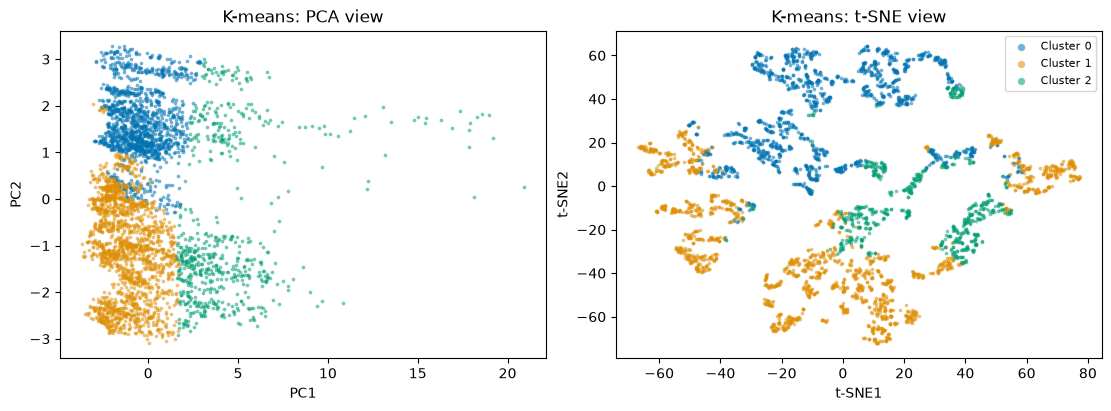

,observations
cluster (-1 = noise),
0,1389
1,1714
2,635


,0,1,2
sp500_log_return,0.000740722,0.00125401,-0.00208545
breakeven_10y,1.97455,2.16829,2.03169
real_yield_10y,0.0518215,0.969621,0.634709
slope_10y_2y,1.51019,0.342345,0.375102
baa_10y_spread,2.71122,1.86047,2.43946
vix,16.1501,15.7203,27.68
vix3m,18.3104,18.1352,27.9679
vix_term_spread,-2.16027,-2.41484,-0.287827
sp500_gold_ratio,1.44645,2.10025,1.89956
sp500_momentum_63d,0.0407949,0.0550289,-0.056211


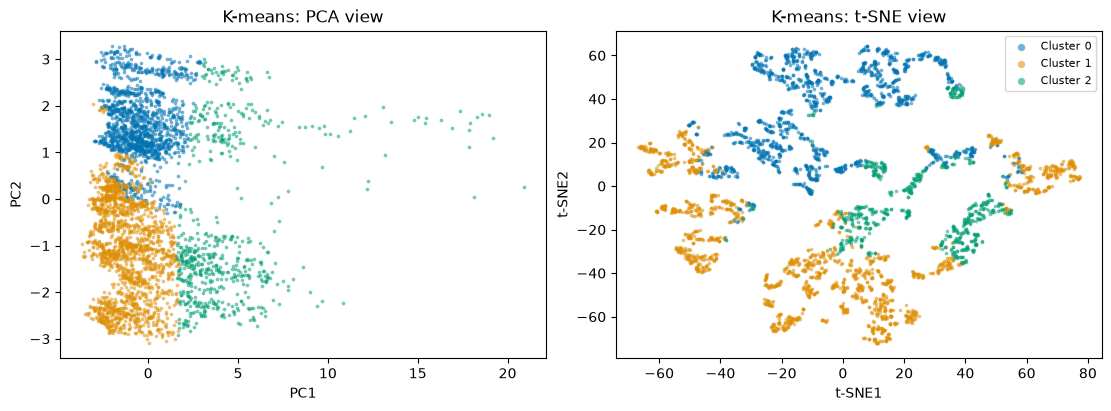

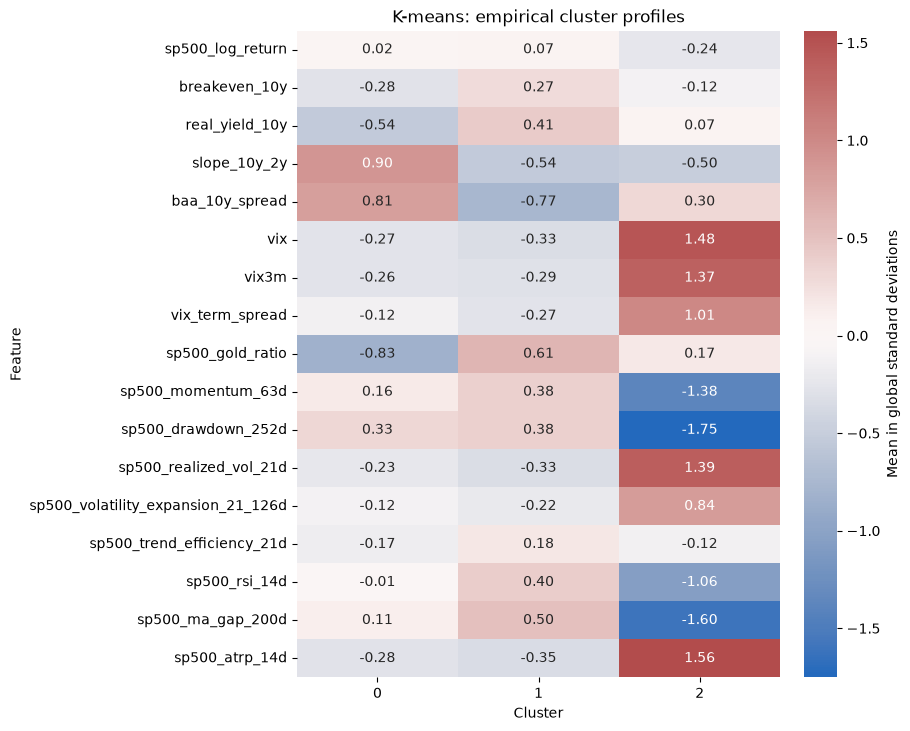

In [17]:
show_model(kmeans_labels, "K-means")


### K-means historical occurrence

Keep the baseline assignments on their original dates. Missing feature rows have no labels. Cluster IDs are categorical and specific to each fitted model; numbers do not imply an ordering of risk or equivalence across models.


In [18]:
df1 = df_transformed.copy()
df1["KM_segments"] = kmeans_labels


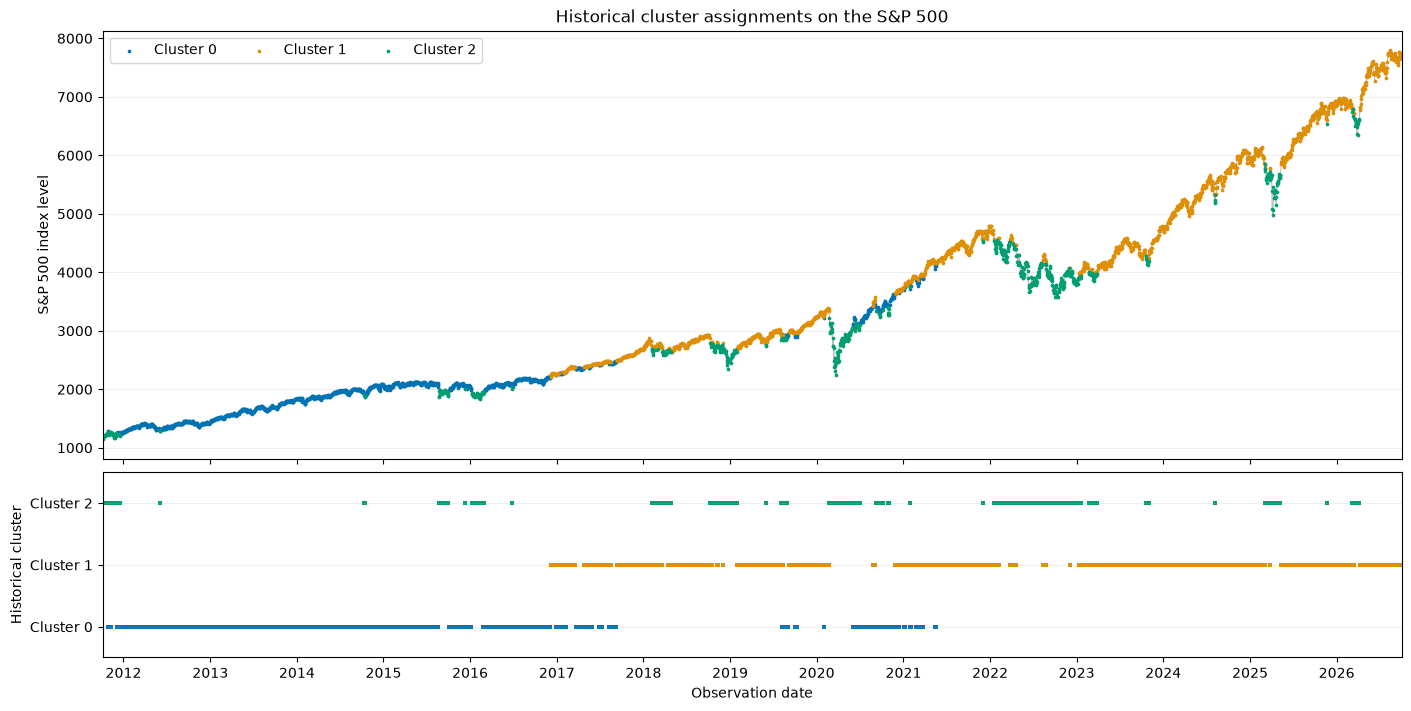

In [19]:
import matplotlib.dates as mdates

CLUSTERING_DIR = Path("data") / "clustering"
CLUSTERING_DIR.mkdir(parents=True, exist_ok=True)

# Align model labels to the original calendar without filling unclassified dates.
cluster_history = df[["sp500"]].join(df1["KM_segments"].rename("cluster"))
cluster_history["cluster"] = cluster_history["cluster"].astype("Int64")
classified_history = cluster_history.dropna(subset=["cluster"])
cluster_ids = np.sort(df1["KM_segments"].unique())
cluster_palette = dict(zip(cluster_ids, sns.color_palette("colorblind", len(cluster_ids))))
assert classified_history.index.equals(df1.index)
assert cluster_history.index.is_unique and cluster_history.index.is_monotonic_increasing

fig, axes = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1.3]}, layout="constrained",
)
axes[0].plot(cluster_history.index, cluster_history["sp500"],
             color="0.75", linewidth=0.8, zorder=1)
for state in cluster_ids:
    observations = classified_history.loc[classified_history["cluster"] == state]
    color = cluster_palette[state]
    axes[0].scatter(observations.index, observations["sp500"],
                    s=7, color=color, linewidths=0, label=f"Cluster {state}", zorder=2)
    axes[1].scatter(observations.index, np.full(len(observations), state),
                    s=8, marker="s", color=color, linewidths=0)
axes[0].set(title="Historical cluster assignments on the S&P 500",
            ylabel="S&P 500 index level")
axes[0].legend(loc="upper left", ncol=len(cluster_ids))
axes[1].set(yticks=cluster_ids,
            yticklabels=[f"Cluster {state}" for state in cluster_ids],
            ylim=(cluster_ids.min() - 0.5, cluster_ids.max() + 0.5),
            ylabel="Historical cluster", xlabel="Observation date")
axes[1].set_xlim(cluster_history.index.min(), cluster_history.index.max())
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for ax in axes:
    ax.grid(axis="y", alpha=0.2)
fig.savefig(CLUSTERING_DIR / "historical_cluster_timeline.png", dpi=160, bbox_inches="tight")
plt.show()
cluster_history.to_csv(CLUSTERING_DIR / "historical_cluster_assignments.csv", index_label="date")


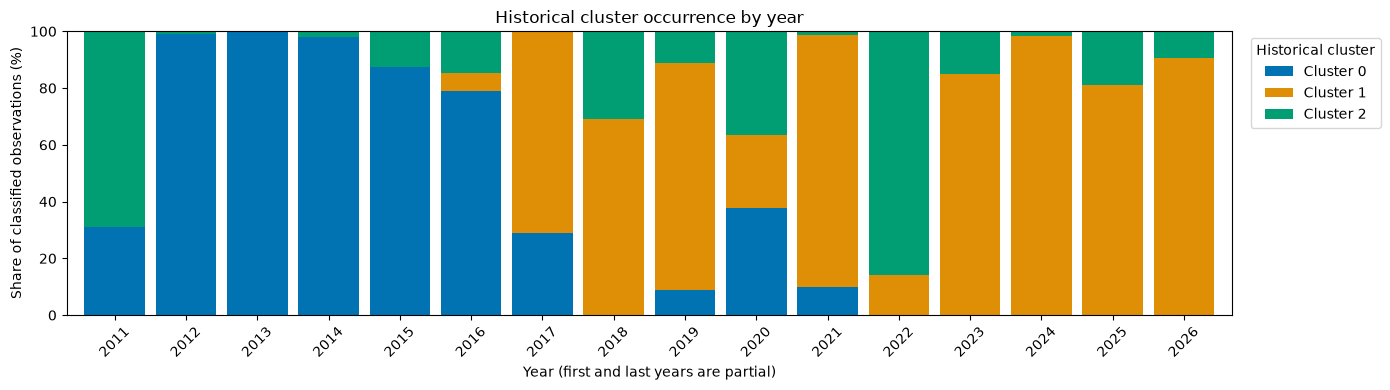

In [20]:
# Annual occurrence is measured among classified observations only.
annual_cluster_counts = pd.crosstab(
    classified_history.index.year,
    classified_history["cluster"].to_numpy(dtype=int),
).reindex(columns=cluster_ids, fill_value=0)
annual_cluster_counts.index.name = "year"
annual_cluster_counts.columns.name = "cluster"
annual_cluster_shares = annual_cluster_counts.div(annual_cluster_counts.sum(axis=1), axis=0) * 100
assert np.allclose(annual_cluster_shares.sum(axis=1), 100)
assert annual_cluster_counts.to_numpy().sum() == len(df1)

ax = annual_cluster_shares.rename(columns=lambda state: f"Cluster {state}").plot.bar(
    stacked=True, figsize=(14, 4), width=0.85,
    color=[cluster_palette[state] for state in cluster_ids],
)
ax.set(title="Historical cluster occurrence by year",
       xlabel="Year (first and last years are partial)",
       ylabel="Share of classified observations (%)", ylim=(0, 100))
ax.legend(title="Historical cluster", loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(CLUSTERING_DIR / "annual_cluster_occurrence.png", dpi=160, bbox_inches="tight")
plt.show()
annual_cluster_counts.to_csv(CLUSTERING_DIR / "annual_cluster_counts.csv")
annual_cluster_shares.to_csv(CLUSTERING_DIR / "annual_cluster_shares.csv")


## 2. K-medoids

Use actual observations as representatives, minimizing the sum of distances to medoids. Recover their dates and original feature values to interpret the states. The model uses [FasterPAM from `kmedoids`](https://python-kmedoids.readthedocs.io/en/latest/), a NumPy-2-compatible backend; the practice notebook's older `sklearn_extra` package is not required.


In [21]:
params = {"n_clusters": 3, "method": "fasterpam", "init": "random", "random_state": 1,
          "metric": "precomputed"}
started = perf_counter()
model_kmedoids = KMedoids(**params).fit(D_fit)
kmedoids_labels = model_kmedoids.labels_
row = cluster_metrics("K-medoids", kmedoids_labels, perf_counter() - started)
row.update(Stage="Baseline", Calibration="Standard", Parameters=params,
           Sum_distances=model_kmedoids.inertia_)
baseline_rows.append(row)
baseline_labels["K-medoids"], BASELINE_PARAMS["K-medoids"] = kmedoids_labels, params
pd.DataFrame([row]).drop(columns="Parameters").round(4)


,Model,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds,Stage,Calibration,Sum_distances
0,K-medoids,3,100.0,0,619,48.5286,0.1647,890.0705,1.8024,0.232,Baseline,Standard,12198.8534


date,2015-04-14,2024-10-02,2018-12-11
sp500_log_return,0.001628,0.000138,-0.000356
breakeven_10y,1.800000,2.210000,1.830000
real_yield_10y,0.100000,1.580000,1.060000
slope_10y_2y,1.370000,0.160000,0.110000
baa_10y_spread,2.540000,1.640000,2.260000
vix,13.670000,18.900000,21.760000
vix3m,15.850000,20.590000,21.720000
vix_term_spread,-2.180000,-1.690000,0.040000
sp500_gold_ratio,1.757076,2.138645,2.123182
sp500_momentum_63d,0.032776,0.030682,-0.090968


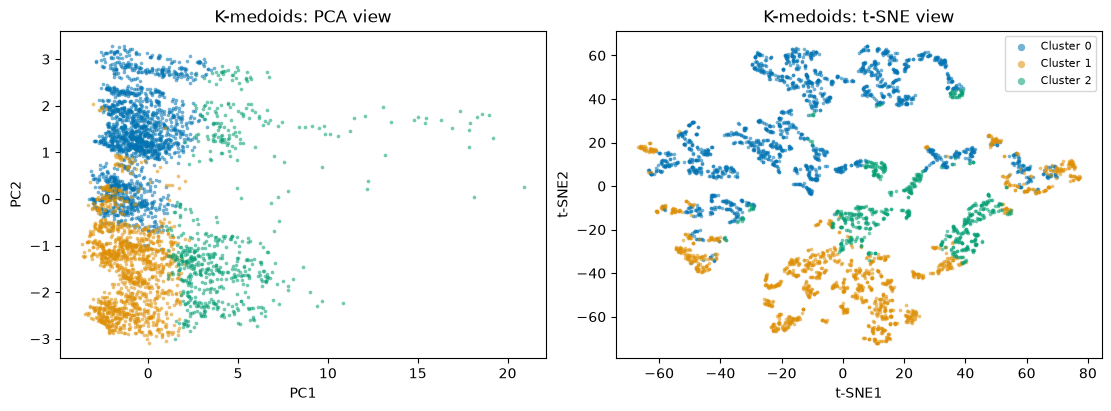

,observations
cluster (-1 = noise),
0,1814
1,1305
2,619


,0,1,2
sp500_log_return,0.00103988,0.000939689,-0.00203337
breakeven_10y,1.95643,2.25573,2.02994
real_yield_10y,0.0626075,1.22473,0.686769
slope_10y_2y,1.33109,0.218284,0.360533
baa_10y_spread,2.58431,1.78051,2.41078
vix,15.7799,16.4666,27.2057
vix3m,18.0439,18.8503,27.3751
vix_term_spread,-2.26394,-2.38375,-0.16937
sp500_gold_ratio,1.58731,2.10386,1.92286
sp500_momentum_63d,0.0441332,0.0568423,-0.0629196


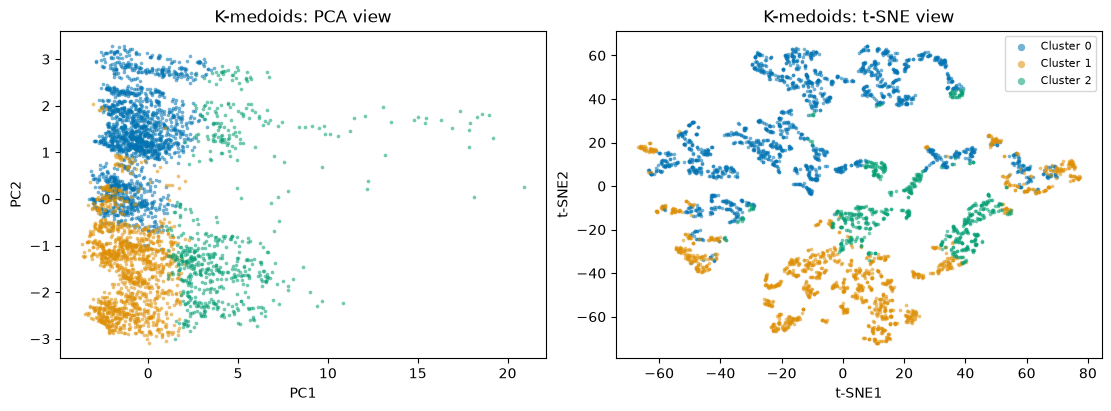

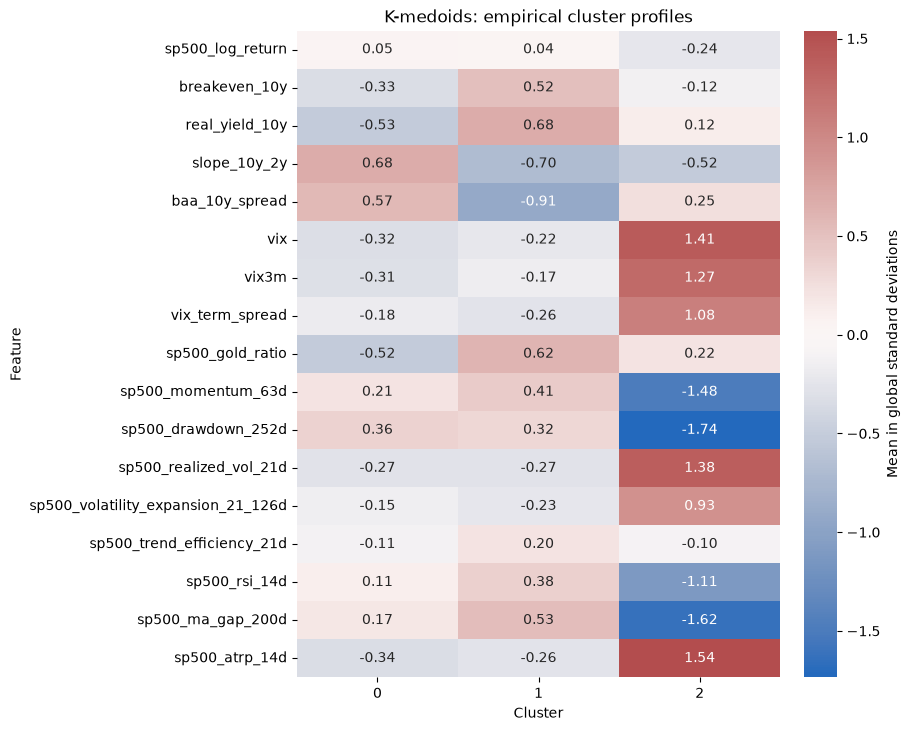

In [22]:
display(df_transformed.iloc[model_kmedoids.medoid_indices_].T)
show_model(kmedoids_labels, "K-medoids")


## 3. Agglomerative clustering

Merge observations into a hierarchy. The baseline uses Ward linkage with Euclidean distance and cuts the tree into three clusters. The dendrogram and cophenetic correlation describe the tree; silhouette/Calinski–Harabasz/Davies–Bouldin describe the chosen partition.


In [23]:
params = {"n_clusters": 3, "metric": "euclidean", "linkage": "ward"}
started = perf_counter()
model_agg = AgglomerativeClustering(**params).fit(X)
agg_labels = model_agg.labels_
row = cluster_metrics("Agglomerative", agg_labels, perf_counter() - started)
ward_linkage = linkage(X, method="ward", metric="euclidean")
cophenetic_correlation, _ = cophenet(ward_linkage, pdist(X))
row.update(Stage="Baseline", Calibration="Standard", Parameters=params,
           Cophenetic=cophenetic_correlation)
baseline_rows.append(row)
baseline_labels["Agglomerative"], BASELINE_PARAMS["Agglomerative"] = agg_labels, params
pd.DataFrame([row]).drop(columns="Parameters").round(4)


,Model,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds,Stage,Calibration,Cophenetic
0,Agglomerative,3,100.0,0,746,56.9556,0.1423,775.3991,1.6908,0.1026,Baseline,Standard,0.5262


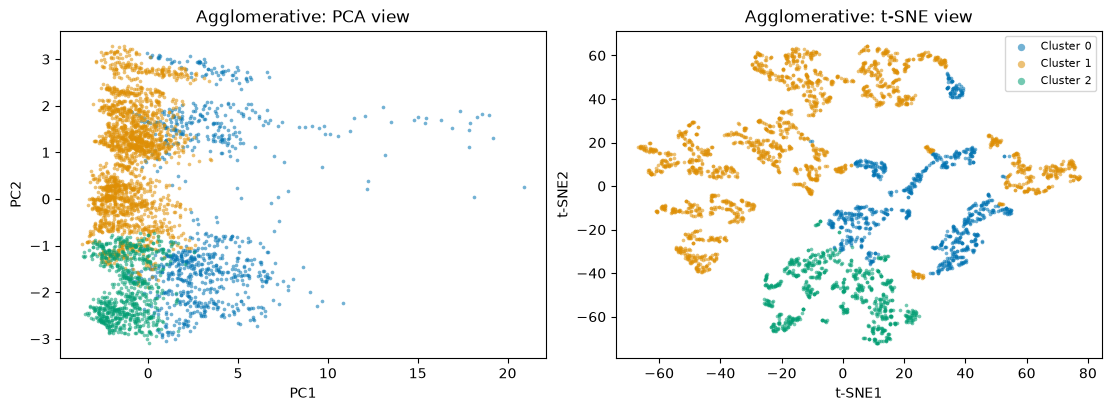

,observations
cluster (-1 = noise),
0,863
1,2129
2,746


,0,1,2
sp500_log_return,-0.000552973,0.000771663,0.000922691
breakeven_10y,2.02238,2.0136,2.30155
real_yield_10y,0.550695,0.0920855,1.96468
slope_10y_2y,0.364287,1.19475,0.0866354
baa_10y_spread,2.42972,2.43309,1.64462
vix,26.0423,15.2365,16.1408
vix3m,27.0047,17.5121,18.3488
vix_term_spread,-0.962387,-2.27559,-2.20795
sp500_gold_ratio,1.88569,1.73571,2.00066
sp500_momentum_63d,-0.0266726,0.0436766,0.0607516


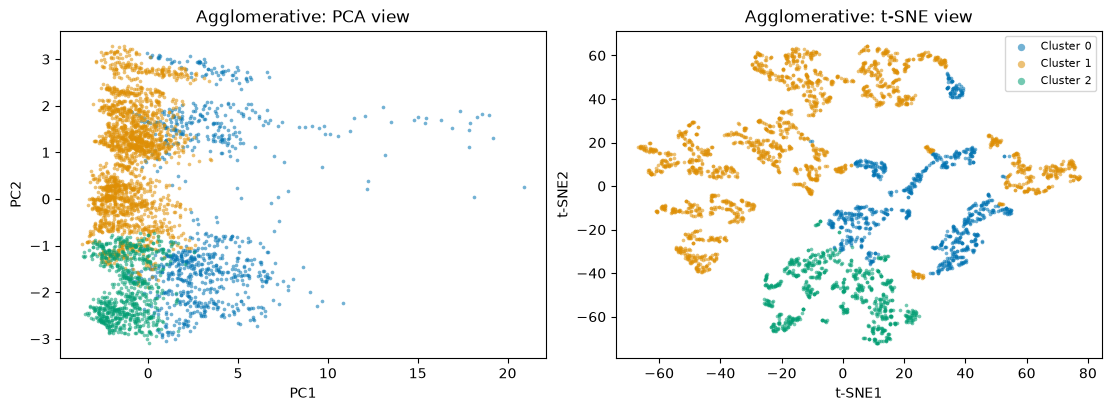

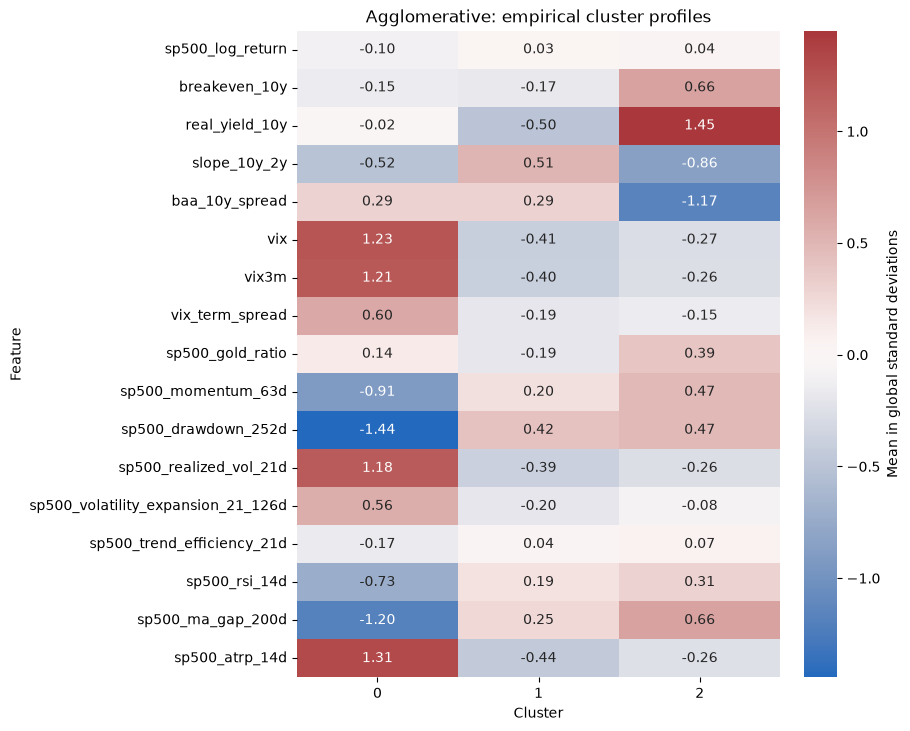

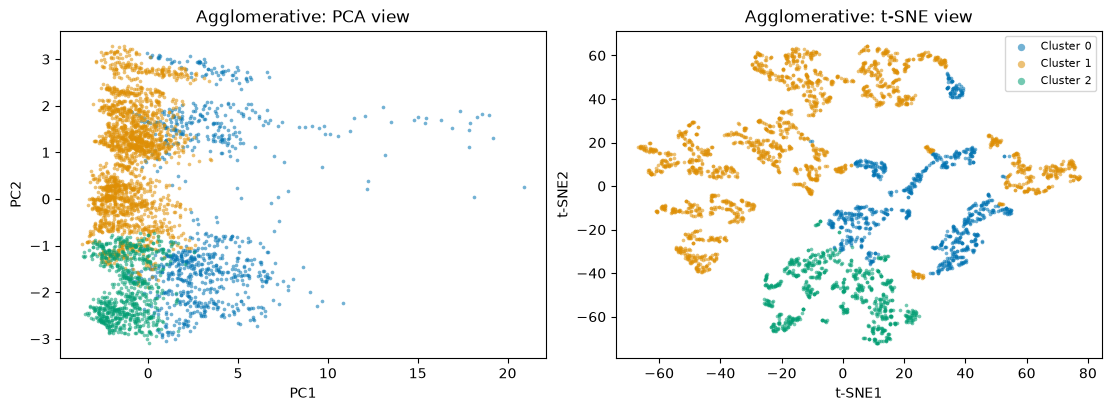

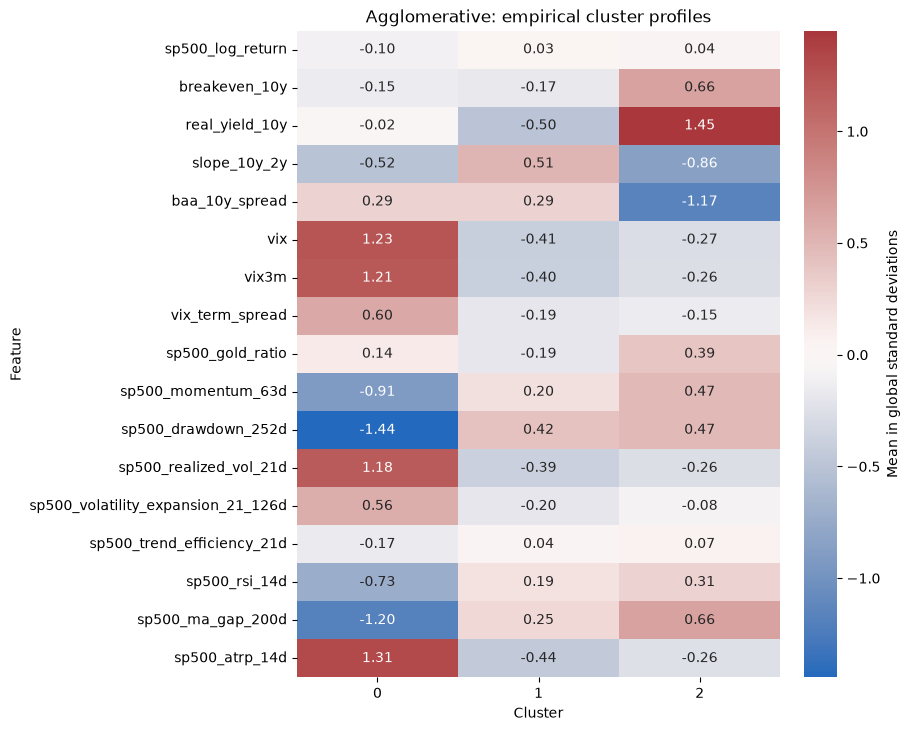

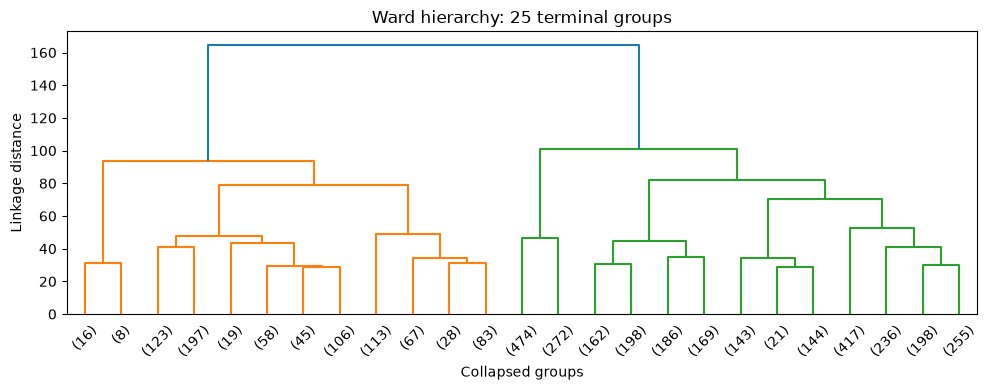

In [24]:
show_model(agg_labels, "Agglomerative")
fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(ward_linkage, truncate_mode="lastp", p=25, show_leaf_counts=True, ax=ax)
ax.set(title="Ward hierarchy: 25 terminal groups", xlabel="Collapsed groups", ylabel="Linkage distance")
plt.tight_layout()
plt.show()


## 4. Gaussian mixture model

Estimate three Gaussian components with full covariance matrices, then assign each row to its most probable component. Inspect convergence and posterior confidence as well as the geometric partition scores. Covariance regularization keeps estimation stable. **Lower AIC/BIC is better only among GMM fits using the same observations and coordinate system.**


In [25]:
params = {"n_components": 3, "covariance_type": "full", "n_init": 5,
          "max_iter": 500, "reg_covar": 1e-5, "random_state": 1}
started = perf_counter()
model_gmm = GaussianMixture(**params).fit(X)
gmm_labels = model_gmm.predict(X)
row = cluster_metrics("GMM", gmm_labels, perf_counter() - started)
row.update(Stage="Baseline", Calibration="Standard", Parameters=params,
           AIC=model_gmm.aic(X), BIC=model_gmm.bic(X), Converged=model_gmm.converged_,
           Iterations=model_gmm.n_iter_, Mean_confidence=model_gmm.predict_proba(X).max(axis=1).mean())
baseline_rows.append(row)
baseline_labels["GMM"], BASELINE_PARAMS["GMM"] = gmm_labels, params
pd.DataFrame([row]).drop(columns="Parameters").round(4)


,Model,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds,Stage,Calibration,AIC,BIC,Converged,Iterations,Mean_confidence
0,GMM,3,100.0,0,790,40.8507,0.147,765.5234,1.8582,0.2196,Baseline,Standard,84793.0574,87644.7056,True,19,0.9937


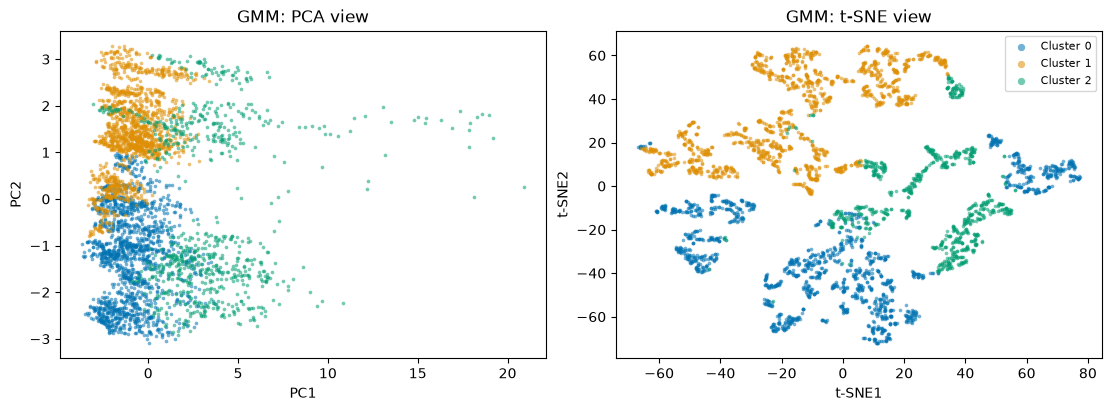

,observations
cluster (-1 = noise),
0,1527
1,1421
2,790


,0,1,2
sp500_log_return,0.000835003,0.00058235,-0.000314666
breakeven_10y,2.18898,1.99068,1.99734
real_yield_10y,1.04182,0.188388,0.352392
slope_10y_2y,0.306608,1.51177,0.387608
baa_10y_spread,1.83622,2.63318,2.47863
vix,16.6402,14.4062,26.6751
vix3m,18.9055,16.5256,27.7529
vix_term_spread,-2.26537,-2.1194,-1.07787
sp500_gold_ratio,2.10317,1.48887,1.88347
sp500_momentum_63d,0.0516515,0.0369392,-0.0203453


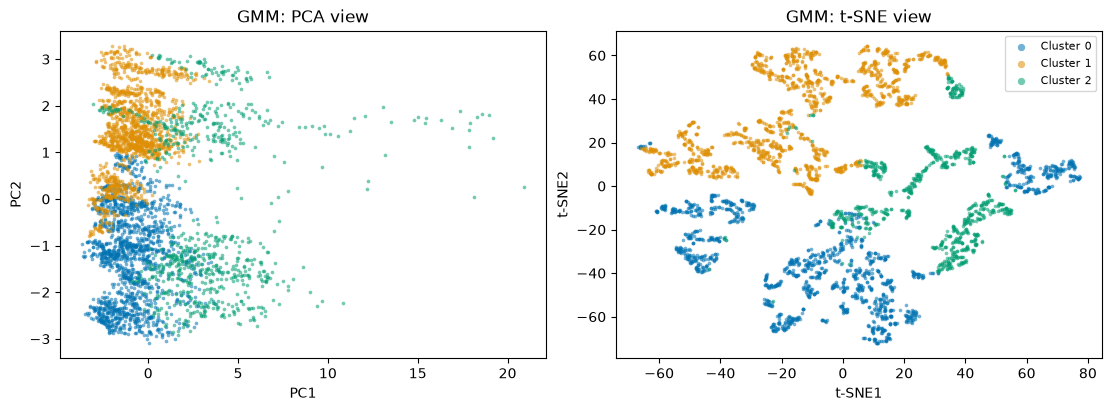

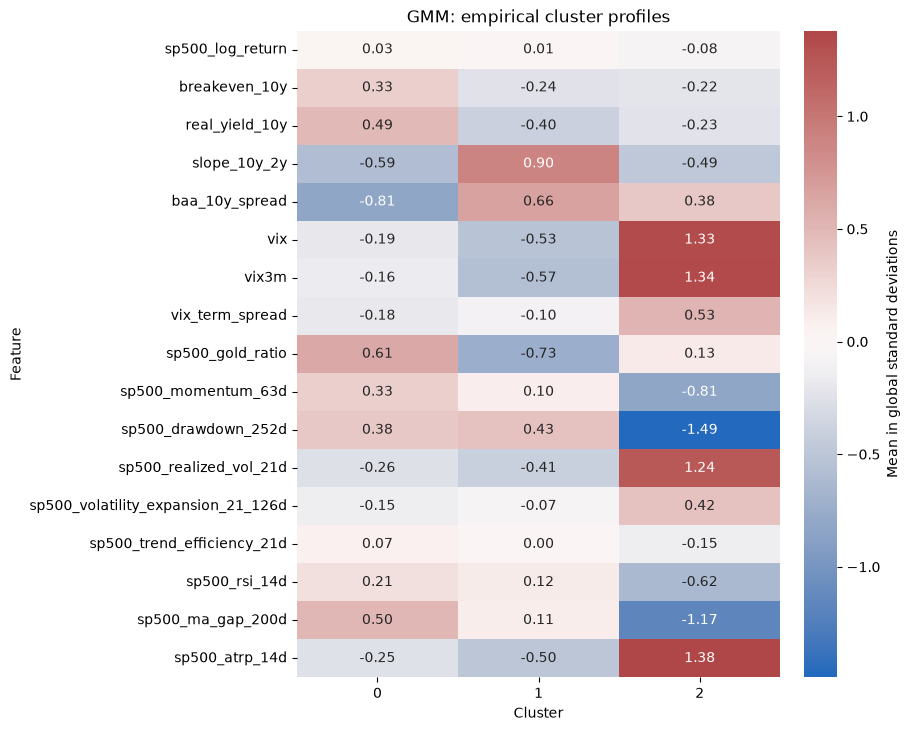

In [26]:
show_model(gmm_labels, "GMM")


## 5. DBSCAN

Find dense regions and label unassigned observations as noise (`-1`). Start with the practice notebook's `eps=3`, `min_samples=10`, then calibrate these to our feature distances in the tuning section. DBSCAN does not accept a fixed cluster count. A single dense group is a valid algorithm result but not a multi-state partition.


In [27]:
params = {"eps": 3.0, "min_samples": 10, "metric": "euclidean"}
started = perf_counter()
model_dbs = DBSCAN(**params).fit(X)
dbscan_labels = model_dbs.labels_
row = cluster_metrics("DBSCAN", dbscan_labels, perf_counter() - started)
row.update(Stage="Baseline", Calibration="Standard", Parameters=params)
baseline_rows.append(row)
baseline_labels["DBSCAN"], BASELINE_PARAMS["DBSCAN"] = dbscan_labels, params
pd.DataFrame([row]).drop(columns="Parameters").round(4)


,Model,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds,Stage,Calibration
0,DBSCAN,1,98.6356,51,3687,100.0,NaN,NaN,NaN,0.0334,Baseline,Standard


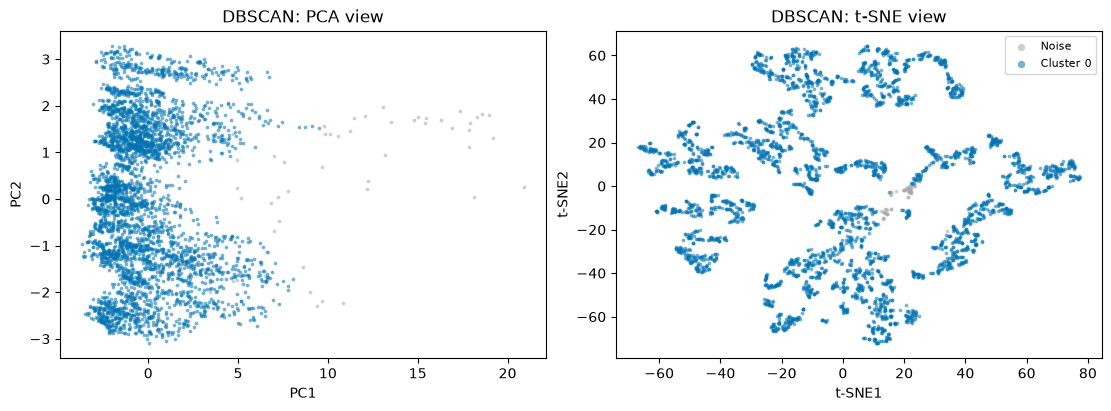

,observations
cluster (-1 = noise),
-1,51
0,3687


,0
sp500_log_return,0.000603866
breakeven_10y,2.08354
real_yield_10y,0.57741
slope_10y_2y,0.786583
baa_10y_spread,2.26375
vix,17.4905
vix3m,19.5608
vix_term_spread,-2.07024
sp500_gold_ratio,1.82489
sp500_momentum_63d,0.0333403


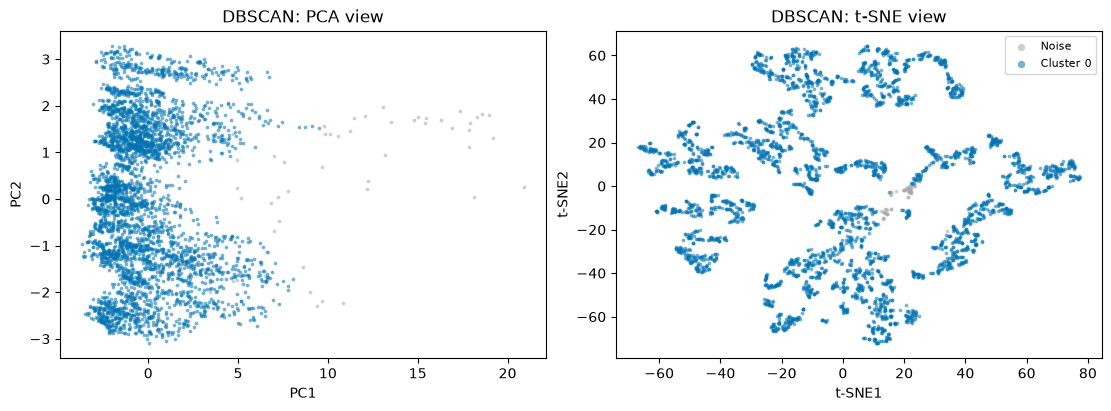

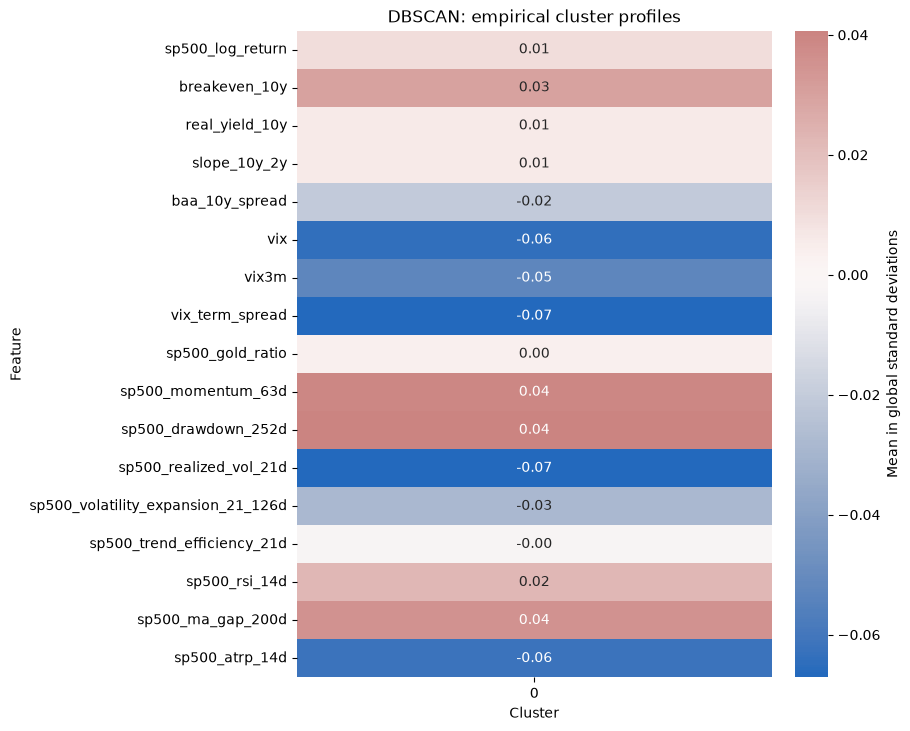

In [28]:
show_model(dbscan_labels, "DBSCAN")


### Baseline comparison

Compare all five starting configurations before tuning. Missing scores indicate an undefined partition score, not a score of zero. DBSCAN coverage and minimum cluster size are part of its interpretation.


In [29]:
baseline_comparison = pd.DataFrame(baseline_rows)
score_columns = ["Model", "Clusters", "Coverage_pct", "Noise_rows", "Min_size", "Largest_cluster_pct",
                 "Silhouette", "Calinski_Harabasz", "Davies_Bouldin", "Fit_seconds"]
display(baseline_comparison[score_columns].round(4))
baseline_comparison.to_csv(CLUSTERING_DIR / "baseline_model_comparison.csv", index=False)
pd.DataFrame(baseline_labels, index=df_transformed.index).to_csv(CLUSTERING_DIR / "baseline_assignments.csv")


,Model,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds
0,K-means,3,100.0000,0,635,45.8534,0.1737,937.2132,1.7560,0.0643
1,K-medoids,3,100.0000,0,619,48.5286,0.1647,890.0705,1.8024,0.2320
2,Agglomerative,3,100.0000,0,746,56.9556,0.1423,775.3991,1.6908,0.1026
3,GMM,3,100.0000,0,790,40.8507,0.1470,765.5234,1.8582,0.2196
4,DBSCAN,1,98.6356,51,3687,100.0000,NaN,NaN,NaN,0.0334


## Tune the models

Try a modest grid on the same standardized feature geometry. Search **2–8 clusters**, multiple medoid starts, hierarchy linkage choices, and GMM covariance types. For DBSCAN, derive `eps` from neighbor-distance quantiles, then vary `min_samples`.

Select K-means/K-medoids/agglomerative candidates by highest silhouette. Select GMM by lowest BIC among converged fits in the fixed 16-dimensional representation. Select DBSCAN by highest silhouette only when **coverage ≥80%, at least two clusters, and every cluster has ≥20 observations**. These are explicit screening choices; the tables retain all trials so they can be changed. Small clusters and imbalance still deserve inspection.


In [30]:
# Shared fitting adapter is used only for tuning and calibration loops.
def fit_model(name, values, params, distances=None):
    if name == "K-means":
        model = KMeans(**params)
    elif name == "K-medoids":
        model = KMedoids(**params)
    elif name == "Agglomerative":
        model = AgglomerativeClustering(**params)
    elif name == "GMM":
        model = GaussianMixture(**params)
    elif name == "DBSCAN":
        model = DBSCAN(**params)
    else:
        raise ValueError(name)
    fit_values = distances if name == "K-medoids" else values
    if name == "K-medoids" and distances is None:
        fit_values = squareform(pdist(values))
    started = perf_counter()
    model.fit(fit_values)
    labels = model.predict(values) if name == "GMM" else model.labels_
    return model, labels, perf_counter() - started


def run_trial(name, values, params, stage="Tuned", calibration="Standard", distances=None):
    model, labels, seconds = fit_model(name, values, params, distances)
    row = cluster_metrics(name, labels, seconds)
    row.update(Stage=stage, Calibration=calibration, Parameters=params.copy())
    if name == "K-means":
        row["Inertia"] = model.inertia_
    elif name == "K-medoids":
        row["Sum_distances"] = model.inertia_
    elif name == "GMM":
        row.update(AIC=model.aic(values), BIC=model.bic(values), Converged=model.converged_)
    return row, labels, model

results_rows = list(baseline_rows)
tuning_rows, tuned_params, tuned_labels = [], {}, {}


### K-means: number of clusters

Use 20 initializations per candidate and compare `k = 2, ..., 8`.


,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds,Inertia,K
0,2,100.0,0,739,80.230070,0.329129,1151.250406,1.493159,0.063909,48577.000442,2
6,8,100.0,0,34,19.341894,0.185566,680.636290,1.546005,0.203809,27903.706313,8
4,6,100.0,0,34,32.744783,0.180290,731.258957,1.489979,0.139313,32098.646316,6
5,7,100.0,0,34,19.796683,0.175919,702.526341,1.485229,0.143769,29837.076572,7
1,3,100.0,0,635,45.853398,0.173712,937.213217,1.755963,0.099633,42311.689583,3
3,5,100.0,0,34,33.172820,0.163754,770.265321,1.569953,0.116226,34813.121439,5
2,4,100.0,0,410,35.152488,0.161542,805.612016,1.662744,0.114949,38577.019448,4


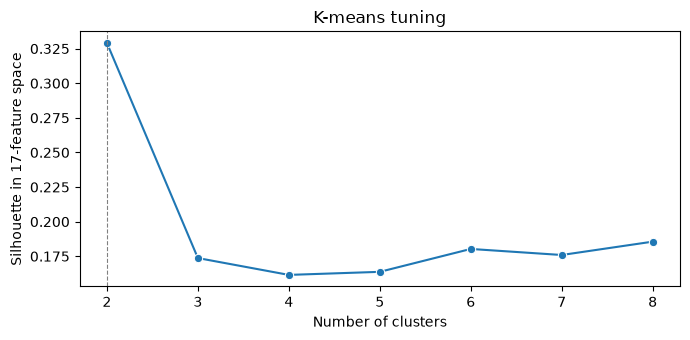

In [31]:
kmeans_rows = []
for k in range(2, 9):
    params = dict(BASELINE_PARAMS["K-means"])
    params.update(n_clusters=k, n_init=20, random_state=1)
    row, labels, model = run_trial("K-means", X, params, stage="Tuning")
    row["K"] = k
    kmeans_rows.append(row)
    tuning_rows.append(row)

kmeans_tuning = pd.DataFrame(kmeans_rows)
kmeans_tuning.to_csv(CLUSTERING_DIR / "kmeans_tuning.csv", index=False)
display(kmeans_tuning.drop(columns=["Parameters", "Model", "Stage", "Calibration"]).sort_values("Silhouette", ascending=False).head(10))

best = kmeans_tuning.dropna(subset=["Silhouette"]).sort_values("Silhouette", ascending=False).iloc[0]
params = dict(best["Parameters"])
row, labels, model = run_trial("K-means", X, params)
results_rows.append(row)
tuned_params["K-means"] = params
tuned_labels["K-means"] = labels

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.lineplot(data=kmeans_tuning, x="K", y="Silhouette", marker="o", ax=ax)
ax.set(title="K-means tuning", xlabel="Number of clusters", ylabel="Silhouette in 17-feature space")
ax.axvline(params["n_clusters"], color="0.5", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()


### K-medoids: cluster count and initialization

Use FasterPAM with two fixed random seeds. Reuse the Euclidean distance matrix `D_fit`.


,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds,Sum_distances,K,Seed
13,8,100.0,0,213,27.100054,0.171485,550.829606,1.752604,0.203458,10090.656676,8,7
10,7,100.0,0,323,28.303906,0.169714,593.692711,1.745346,0.195201,10368.669088,7,1
11,7,100.0,0,323,28.303906,0.169714,593.692711,1.745346,0.156154,10368.669088,7,7
2,3,100.0,0,619,48.528625,0.164696,890.070540,1.802375,0.192967,12198.853412,3,1
3,3,100.0,0,619,48.528625,0.164696,890.070540,1.802375,0.123904,12198.853412,3,7
8,6,100.0,0,380,28.624933,0.163157,612.043373,1.607159,0.123710,10668.283348,6,1
9,6,100.0,0,380,28.624933,0.163157,612.043373,1.607159,0.116139,10668.283348,6,7
4,4,100.0,0,621,38.496522,0.151744,756.702162,1.720316,0.126475,11622.237071,4,1
5,4,100.0,0,621,38.496522,0.151744,756.702162,1.720316,0.117490,11622.237071,4,7
0,2,100.0,0,1861,50.214018,0.149654,627.331805,2.208590,0.153227,13319.263748,2,1


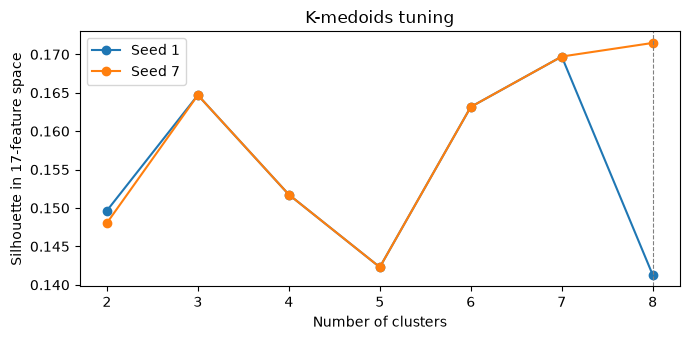

In [32]:
kmedoids_rows = []
for k in range(2, 9):
    for seed in [1, 7]:
        params = dict(BASELINE_PARAMS["K-medoids"])
        params.update(n_clusters=k, method="fasterpam", random_state=seed)
        row, labels, model = run_trial("K-medoids", X, params, stage="Tuning", distances=D_fit)
        row.update(K=k, Seed=seed)
        kmedoids_rows.append(row)
        tuning_rows.append(row)

kmedoids_tuning = pd.DataFrame(kmedoids_rows)
kmedoids_tuning.to_csv(CLUSTERING_DIR / "kmedoids_tuning.csv", index=False)
display(kmedoids_tuning.drop(columns=["Parameters", "Model", "Stage", "Calibration"]).sort_values("Silhouette", ascending=False).head(10))

best = kmedoids_tuning.dropna(subset=["Silhouette"]).sort_values("Silhouette", ascending=False).iloc[0]
params = dict(best["Parameters"])
row, labels, model = run_trial("K-medoids", X, params, distances=D_fit)
results_rows.append(row)
tuned_params["K-medoids"] = params
tuned_labels["K-medoids"] = labels

fig, ax = plt.subplots(figsize=(7, 3.5))
for seed, candidates in kmedoids_tuning.groupby("Seed"):
    ax.plot(candidates["K"], candidates["Silhouette"], marker="o", label=f"Seed {seed}")
ax.set(title="K-medoids tuning", xlabel="Number of clusters", ylabel="Silhouette in 17-feature space")
ax.axvline(params["n_clusters"], color="0.5", linestyle="--", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


### Agglomerative: cluster count and linkage

Compare Ward, average and complete linkage with Euclidean distances.


,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds,K,Linkage
14,2,100.0,0,9,99.759230,0.738608,217.158791,0.464236,0.089462,2,complete
7,2,100.0,0,30,99.197432,0.679940,462.545929,0.643048,0.069500,2,average
8,3,100.0,0,2,99.197432,0.668938,246.786593,0.587193,0.079904,3,average
15,3,100.0,0,9,99.224184,0.636051,232.439636,0.960563,0.075188,3,complete
16,4,100.0,0,9,98.796148,0.527138,195.956423,0.970732,0.069869,4,complete
9,4,100.0,0,2,98.501873,0.501233,212.035479,0.941697,0.076726,4,average
10,5,100.0,0,2,98.501873,0.500823,164.377238,0.915733,0.075553,5,average
12,7,100.0,0,2,98.501873,0.474417,117.808008,0.833329,0.068799,7,average
11,6,100.0,0,2,98.501873,0.474108,136.930718,0.826307,0.072324,6,average
13,8,100.0,0,1,98.501873,0.451656,101.664670,0.784999,0.082202,8,average


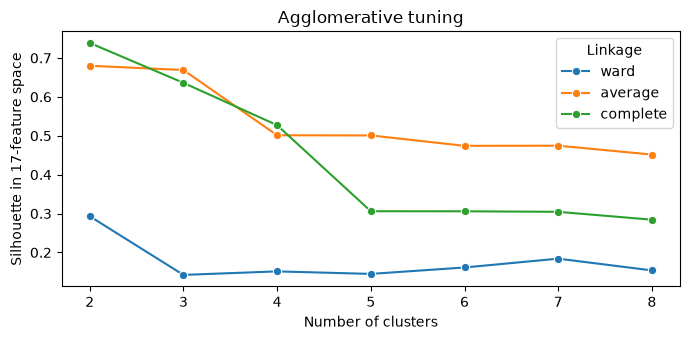

In [33]:
agglomerative_rows = []
for linkage_name in ["ward", "average", "complete"]:
    for k in range(2, 9):
        params = dict(BASELINE_PARAMS["Agglomerative"])
        params.update(n_clusters=k, linkage=linkage_name, metric="euclidean")
        row, labels, model = run_trial("Agglomerative", X, params, stage="Tuning")
        row.update(K=k, Linkage=linkage_name)
        agglomerative_rows.append(row)
        tuning_rows.append(row)

agglomerative_tuning = pd.DataFrame(agglomerative_rows)
agglomerative_tuning.to_csv(CLUSTERING_DIR / "agglomerative_tuning.csv", index=False)
display(agglomerative_tuning.drop(columns=["Parameters", "Model", "Stage", "Calibration"]).sort_values("Silhouette", ascending=False).head(10))

best = agglomerative_tuning.dropna(subset=["Silhouette"]).sort_values("Silhouette", ascending=False).iloc[0]
params = dict(best["Parameters"])
row, labels, model = run_trial("Agglomerative", X, params)
results_rows.append(row)
tuned_params["Agglomerative"] = params
tuned_labels["Agglomerative"] = labels

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.lineplot(data=agglomerative_tuning, x="K", y="Silhouette", hue="Linkage", marker="o", ax=ax)
ax.set(title="Agglomerative tuning", xlabel="Number of clusters", ylabel="Silhouette in 17-feature space")
plt.tight_layout()
plt.show()


### GMM: components and covariance

Compare four covariance structures with three initializations and covariance regularization. BIC and AIC here refer to the same fixed informative PCA coordinates; they are not compared with likelihoods from a different PCA dimension. Geometric scores remain in the original 17-feature space.


,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds,AIC,BIC,Converged,K,Covariance
6,8,100.0,0,39,25.334403,0.153109,578.817177,1.727456,0.255928,52877.134869,60491.907092,True,8,full
5,7,100.0,0,45,25.468165,0.137506,580.451933,1.819030,0.195295,57815.538049,64477.685457,True,7,full
4,6,100.0,0,402,25.601926,0.125467,506.710642,1.922846,0.253182,60264.195708,65973.718299,True,6,full
3,5,100.0,0,258,35.152488,0.184195,645.938736,1.714847,0.140110,69384.647608,74141.545383,True,5,full
2,4,100.0,0,557,31.353665,0.112072,632.128989,2.066531,0.106339,80426.353468,84230.626426,True,4,full
1,3,100.0,0,790,40.850722,0.147008,765.523363,1.858239,0.060513,84793.057439,87644.705581,True,3,full
13,8,100.0,0,29,23.220974,0.148197,422.446642,1.945557,0.100995,93204.882493,94892.211416,True,8,tied
12,7,100.0,0,29,23.194222,0.137363,440.086153,2.053212,0.069202,95762.433946,97343.915667,True,7,tied
20,8,100.0,0,60,19.662921,0.157652,549.289127,1.567068,0.079203,97759.008571,99396.527045,True,8,diag
19,7,100.0,0,71,25.066881,0.139985,516.262207,1.581521,0.065143,99683.783702,101115.834079,True,7,diag


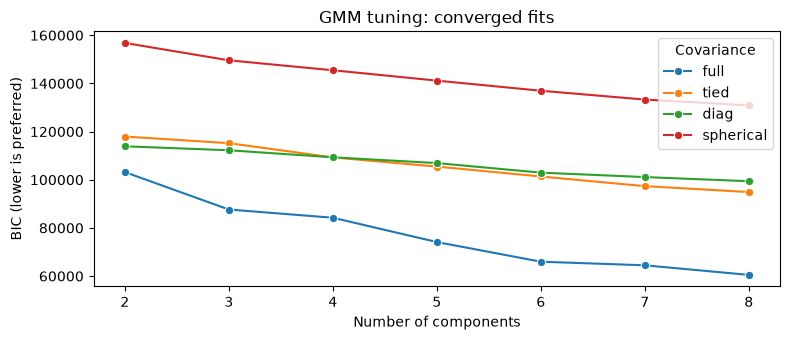

In [34]:
gmm_rows = []
for covariance_type in ["full", "tied", "diag", "spherical"]:
    for k in range(2, 9):
        params = dict(BASELINE_PARAMS["GMM"])
        params.update(n_components=k, covariance_type=covariance_type,
                      n_init=3, max_iter=500, reg_covar=1e-5, random_state=1)
        row, labels, model = run_trial("GMM", X, params, stage="Tuning")
        row.update(K=k, Covariance=covariance_type)
        gmm_rows.append(row)
        tuning_rows.append(row)

gmm_tuning = pd.DataFrame(gmm_rows)
gmm_tuning.to_csv(CLUSTERING_DIR / "gmm_tuning.csv", index=False)
display(gmm_tuning.drop(columns=["Parameters", "Model", "Stage", "Calibration"]).sort_values(["Converged", "BIC"], ascending=[False, True]).head(10))

converged_gmm = gmm_tuning.loc[gmm_tuning["Converged"].fillna(False).astype(bool)].dropna(subset=["BIC"])
if converged_gmm.empty:
    raise RuntimeError("No GMM candidate converged; inspect the GMM tuning table.")
best = converged_gmm.sort_values("BIC").iloc[0]
params = dict(best["Parameters"])
row, labels, model = run_trial("GMM", X, params)
results_rows.append(row)
tuned_params["GMM"] = params
tuned_labels["GMM"] = labels

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.lineplot(data=converged_gmm, x="K", y="BIC", hue="Covariance", marker="o", ax=ax)
ax.set(title="GMM tuning: converged fits", xlabel="Number of components", ylabel="BIC (lower is preferred)")
plt.tight_layout()
plt.show()


### DBSCAN: neighborhood size and radius

For each `min_samples`, calculate the distance to that neighbor **including the observation itself**, matching DBSCAN's neighborhood convention. Test five quantiles of those distances as radii. The silhouette table and heatmaps exclude noise; the eligibility gate also checks coverage and the smallest cluster.


,Clusters,Coverage_pct,Noise_rows,Min_size,Largest_cluster_pct,Silhouette,Calinski_Harabasz,Davies_Bouldin,Fit_seconds,Min_samples,Eps_quantile,Eps,Eligible
12,4,92.001070,299,24,87.845304,0.102660,131.727295,1.459658,0.012182,20,0.80,2.208492,True
11,4,81.861958,678,20,89.836601,0.093530,114.732540,1.322282,0.010790,20,0.65,1.853213,True
9,2,97.940075,77,16,99.562961,0.312523,48.332230,0.805685,0.028041,10,0.95,2.488548,False
8,3,96.254682,140,11,99.138410,0.305306,52.609250,0.774454,0.011606,10,0.90,2.124489,False
4,4,97.298020,101,4,98.652736,0.229041,48.069627,0.870826,0.012598,5,0.95,1.987329,False
10,7,72.980203,1010,20,59.200880,0.161985,252.166423,1.231060,0.011855,20,0.50,1.647230,False
0,95,65.650080,1284,4,18.296659,0.117558,89.627355,1.047644,0.010122,5,0.50,1.036019,False
6,14,80.444088,731,8,59.594280,0.109329,128.173752,1.058455,0.010137,10,0.65,1.521941,False
3,14,95.639379,163,4,84.559441,0.066393,69.379799,1.201509,0.012390,5,0.90,1.701129,False
7,10,90.636704,350,10,86.481700,0.059358,78.113129,1.123794,0.012168,10,0.80,1.817645,False


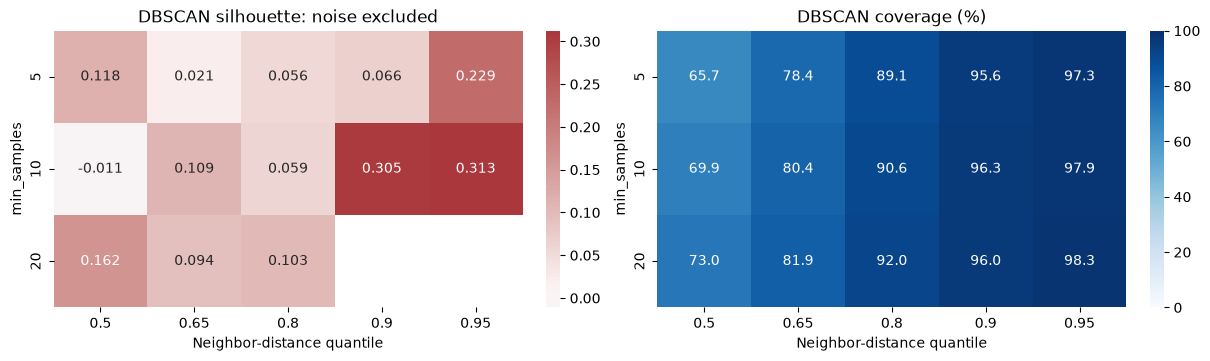

In [35]:
dbscan_rows = []
for min_samples in [5, 10, 20]:
    neighbor_distances = NearestNeighbors(n_neighbors=min_samples).fit(X).kneighbors(X)[0][:, -1]
    for quantile in [0.50, 0.65, 0.80, 0.90, 0.95]:
        eps = float(np.quantile(neighbor_distances, quantile))
        params = dict(BASELINE_PARAMS["DBSCAN"])
        params.update(eps=eps, min_samples=min_samples)
        row, labels, model = run_trial("DBSCAN", X, params, stage="Tuning")
        row.update(Min_samples=min_samples, Eps_quantile=quantile, Eps=eps)
        row["Eligible"] = (row["Coverage_pct"] >= 80 and row["Clusters"] >= 2
                           and row["Min_size"] >= 20 and np.isfinite(row["Silhouette"]))
        dbscan_rows.append(row)
        tuning_rows.append(row)

dbscan_tuning = pd.DataFrame(dbscan_rows)
dbscan_tuning.to_csv(CLUSTERING_DIR / "dbscan_tuning.csv", index=False)
display(dbscan_tuning.drop(columns=["Parameters", "Model", "Stage", "Calibration"]).sort_values(["Eligible", "Silhouette", "Coverage_pct"],
                                 ascending=[False, False, False]).head(10))

eligible_dbscan = dbscan_tuning.loc[dbscan_tuning["Eligible"]]
if eligible_dbscan.empty:
    print("No DBSCAN candidate meets the screening rules; retain the highest-coverage trial for inspection.")
    best = dbscan_tuning.sort_values("Coverage_pct", ascending=False).iloc[0]
else:
    best = eligible_dbscan.sort_values(["Silhouette", "Coverage_pct"], ascending=[False, False]).iloc[0]
params = dict(best["Parameters"])
tuned_dbscan_quantile = float(best["Eps_quantile"])
row, labels, model = run_trial("DBSCAN", X, params)
row["Eps_quantile"] = tuned_dbscan_quantile
results_rows.append(row)
tuned_params["DBSCAN"] = params
tuned_labels["DBSCAN"] = labels

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), layout="constrained")
sns.heatmap(dbscan_tuning.pivot(index="Min_samples", columns="Eps_quantile", values="Silhouette"),
            annot=True, fmt=".3f", cmap="vlag", center=0, ax=axes[0])
sns.heatmap(dbscan_tuning.pivot(index="Min_samples", columns="Eps_quantile", values="Coverage_pct"),
            annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100, ax=axes[1])
axes[0].set(title="DBSCAN silhouette: noise excluded", xlabel="Neighbor-distance quantile", ylabel="min_samples")
axes[1].set(title="DBSCAN coverage (%)", xlabel="Neighbor-distance quantile", ylabel="min_samples")
plt.show()


### Hierarchical distance diagnostic

Compare how well each hierarchy preserves its own input distances using cophenetic correlation. Use the **same condensed distance vector** for `linkage` and `cophenet`. Mahalanobis uses the covariance of the informative PCA coordinates. Ward is included only for Euclidean distance.

This diagnostic is separate from the Agglomerative cluster-count selection above: preserving pairwise distances does not establish cluster separation or investment usefulness.


,Distance,Linkage,Cophenetic_correlation
9,mahalanobis,average,0.848410
2,euclidean,average,0.828260
6,chebyshev,average,0.799758
7,mahalanobis,single,0.768959
1,euclidean,complete,0.767387
0,euclidean,single,0.762601
5,chebyshev,complete,0.726976
4,chebyshev,single,0.721531
8,mahalanobis,complete,0.672758
3,euclidean,ward,0.526221


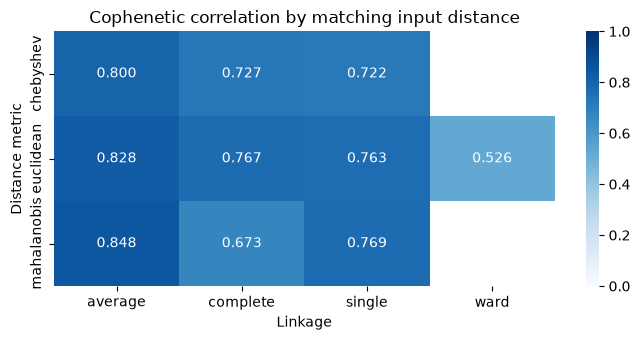

In [36]:
cophenetic_rows = []
for distance_metric in ["euclidean", "chebyshev", "mahalanobis"]:
    if distance_metric == "mahalanobis":
        inverse_covariance = np.linalg.pinv(np.cov(X, rowvar=False, ddof=1))
        distances = pdist(X, metric=distance_metric, VI=inverse_covariance)
    else:
        distances = pdist(X, metric=distance_metric)
    linkage_methods = ["single", "complete", "average"]
    if distance_metric == "euclidean":
        linkage_methods.append("ward")
    for linkage_method in linkage_methods:
        tree = linkage(distances, method=linkage_method)
        correlation, _ = cophenet(tree, distances)
        cophenetic_rows.append({"Distance": distance_metric, "Linkage": linkage_method,
                                "Cophenetic_correlation": float(correlation)})

cophenetic_tuning = pd.DataFrame(cophenetic_rows)
cophenetic_tuning.to_csv(CLUSTERING_DIR / "hierarchical_cophenetic_tuning.csv", index=False)
display(cophenetic_tuning.sort_values("Cophenetic_correlation", ascending=False).head(10))
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(cophenetic_tuning.pivot(index="Distance", columns="Linkage", values="Cophenetic_correlation"),
            annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set(title="Cophenetic correlation by matching input distance", xlabel="Linkage", ylabel="Distance metric")
plt.tight_layout()
plt.show()


## Different calibrations

Keep each selected model's parameters and compare three input geometries: standard scaling with all informative PCs; standard scaling with **95% PCA variance retained**; and median/IQR **robust scaling** with all informative PCs. Every geometric score still uses the original 17 standardized features, so a reduced dimension cannot improve the score merely by changing where it is measured.

For DBSCAN, recompute the selected neighbor-distance quantile in each input geometry; the numeric radius depends on scaling and dimension. The adjusted Rand index (ARI) compares each calibration's assignments with the tuned standard fit. For DBSCAN it uses observations assigned in both fits and reports their shared coverage. **ARI=1 means the partitions agree, even if label numbers differ.**

GMM AIC/BIC are not ranked across these calibrations: dimension and scaling change the likelihood's coordinate system.


In [37]:
pca95 = PCA(n_components=0.95, random_state=1)
X_pca95 = pca95.fit_transform(Z_eval)
robust_scaler = RobustScaler()
robust_values = robust_scaler.fit_transform(subset)
robust_pca = PCA(n_components=np.linalg.matrix_rank(robust_values - robust_values.mean(axis=0)), random_state=1)
X_robust = robust_pca.fit_transform(robust_values)

calibrations = {"PCA95": X_pca95, "Robust": X_robust}
display(pd.DataFrame({
    "Calibration": ["Standard", "PCA95", "Robust"],
    "Fit_dimensions": [X.shape[1], X_pca95.shape[1], X_robust.shape[1]],
    "Variance_retained": [1.0, pca95.explained_variance_ratio_.sum(), 1.0],
}))


,Calibration,Fit_dimensions,Variance_retained
0,Standard,16,1.000000
1,PCA95,10,0.956776
2,Robust,16,1.000000


In [38]:
calibration_rows, calibration_labels = [], {}
for calibration, values in calibrations.items():
    distances = squareform(pdist(values))
    for name, selected_params in tuned_params.items():
        params = selected_params.copy()
        if name == "DBSCAN":
            neighbors = NearestNeighbors(n_neighbors=params["min_samples"]).fit(values)
            neighbor_distances = neighbors.kneighbors(values)[0][:, -1]
            params["eps"] = float(np.quantile(neighbor_distances, tuned_dbscan_quantile))
        row, labels, model = run_trial(name, values, params, stage="Calibration",
                                       calibration=calibration, distances=distances)
        reference = tuned_labels[name]
        common = (reference >= 0) & (labels >= 0)
        valid = common.sum() > 1 and len(np.unique(reference[common])) > 1 and len(np.unique(labels[common])) > 1
        row["ARI_vs_standard"] = adjusted_rand_score(reference[common], labels[common]) if valid else np.nan
        row["Shared_assigned_pct"] = 100 * common.mean()
        if name == "DBSCAN":
            row["Eps_quantile"] = tuned_dbscan_quantile
        calibration_rows.append(row)
        results_rows.append(row)
        calibration_labels[f"{name} / {calibration}"] = labels

calibration_comparison = pd.DataFrame(calibration_rows)
display(calibration_comparison[["Model", "Calibration", "Clusters", "Coverage_pct", "Min_size",
                                 "Silhouette", "Calinski_Harabasz", "Davies_Bouldin",
                                 "ARI_vs_standard", "Shared_assigned_pct"]].round(4))
calibration_comparison.to_csv(CLUSTERING_DIR / "calibration_comparison.csv", index=False)


,Model,Calibration,Clusters,Coverage_pct,Min_size,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI_vs_standard,Shared_assigned_pct
0,K-means,PCA95,2,100.0000,738,0.3291,1151.2386,1.4921,0.9963,100.0000
1,K-medoids,PCA95,8,100.0000,246,0.1701,573.2137,1.7078,0.7614,100.0000
2,Agglomerative,PCA95,2,100.0000,18,0.6654,238.0239,0.7553,0.5895,100.0000
3,GMM,PCA95,8,100.0000,63,0.1380,474.7609,1.8317,0.5054,100.0000
4,DBSCAN,PCA95,3,91.9208,37,0.1136,163.3338,1.6328,0.9653,91.0915
5,K-means,Robust,2,100.0000,671,0.3421,1145.0592,1.4546,0.9159,100.0000
6,K-medoids,Robust,8,100.0000,198,0.1636,549.7966,1.7956,0.8387,100.0000
7,Agglomerative,Robust,2,100.0000,22,0.7109,415.1982,0.5840,0.5772,100.0000
8,GMM,Robust,8,100.0000,69,0.1448,541.4043,1.6932,0.6487,100.0000
9,DBSCAN,Robust,5,91.1985,19,0.0970,123.0397,1.2892,0.9720,90.8775


### Initialization stability

Repeat the **tuned standard** K-means, K-medoids and GMM configurations with seeds 1, 7 and 21. Mean pairwise ARI measures sensitivity to initialization, using all historical rows; it is not an out-of-sample test. Hierarchical clustering and DBSCAN are deterministic at fixed settings, so they do not receive a random-seed stability score.


In [39]:
stability_rows = []
for name in ["K-means", "K-medoids", "GMM"]:
    runs, converged = [], []
    for seed in [1, 7, 21]:
        params = tuned_params[name].copy()
        params["random_state"] = seed
        model, labels, seconds = fit_model(name, X, params, distances=D_fit)
        runs.append(labels)
        converged.append(bool(getattr(model, "converged_", True)))
    agreements = [adjusted_rand_score(runs[i], runs[j]) for i in range(3) for j in range(i + 1, 3)]
    stability_rows.append({"Model": name, "Mean_ARI": np.mean(agreements),
                           "Min_ARI": np.min(agreements), "All_converged": all(converged)})

stability_df = pd.DataFrame(stability_rows).set_index("Model")
display(stability_df.round(4))
stability_df.to_csv(CLUSTERING_DIR / "initialization_stability.csv")
for row in results_rows:
    if row["Stage"] == "Tuned" and row["Calibration"] == "Standard" and row["Model"] in stability_df.index:
        row["Seed_stability_ARI"] = stability_df.loc[row["Model"], "Mean_ARI"]


,Mean_ARI,Min_ARI,All_converged
Model,,,
K-means,1.0000,1.0000,True
K-medoids,0.6450,0.5348,True
GMM,0.9996,0.9994,True


### Inspect the tuned partitions

Compare the selected standard fits on the same PCA axes. Labels are model-specific; DBSCAN noise remains gray. This visual check complements the scores and reveals small groups or strong imbalance.


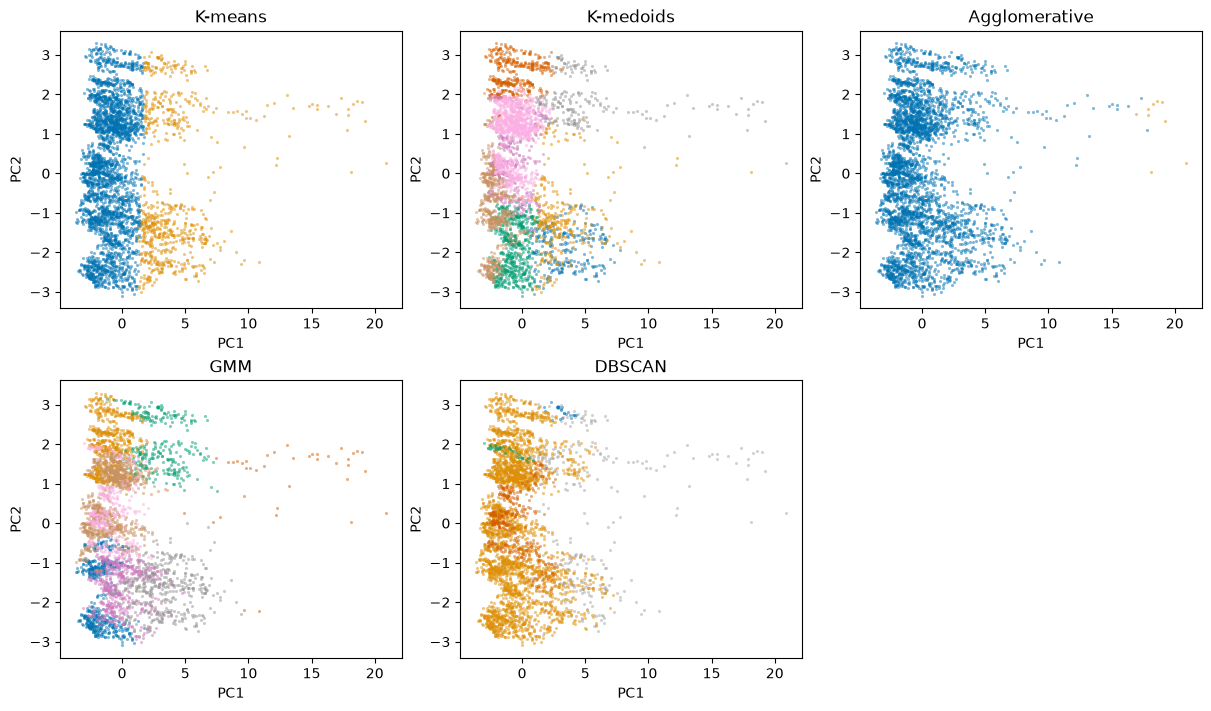

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), layout="constrained")
for ax, (name, labels) in zip(axes.flat, tuned_labels.items()):
    groups = np.unique(labels)
    colors = dict(zip(groups[groups >= 0], sns.color_palette("colorblind", (groups >= 0).sum())))
    colors[-1] = "0.65"
    for group in groups:
        mask = labels == group
        ax.scatter(data_pca.iloc[mask, 0], data_pca.iloc[mask, 1], s=5, alpha=0.5,
                   color=colors[group], linewidths=0)
    ax.set(title=name, xlabel="PC1", ylabel="PC2")
axes.flat[-1].set_visible(False)
fig.savefig(CLUSTERING_DIR / "tuned_model_partitions.png", dpi=160, bbox_inches="tight")
plt.show()


## Final comparison

The table below brings together **all five baselines, five tuned configurations, and ten calibration checks**. Higher silhouette/Calinski–Harabasz and lower Davies–Bouldin indicate more compact geometric partitions. Read coverage, smallest cluster and largest-cluster share alongside those scores. `Eligible` applies the stated DBSCAN screening rules and GMM convergence check; it does not declare a model suitable for investment decisions.

The chart compares the five selected **tuned standard** configurations. Native objectives are shown separately: squared-distance inertia, medoid distance loss, and GMM AIC/BIC are different quantities. Missing values mean a metric is undefined or not applicable. Complete configurations, all trial scores and dated labels are exported under `data/clustering/`.


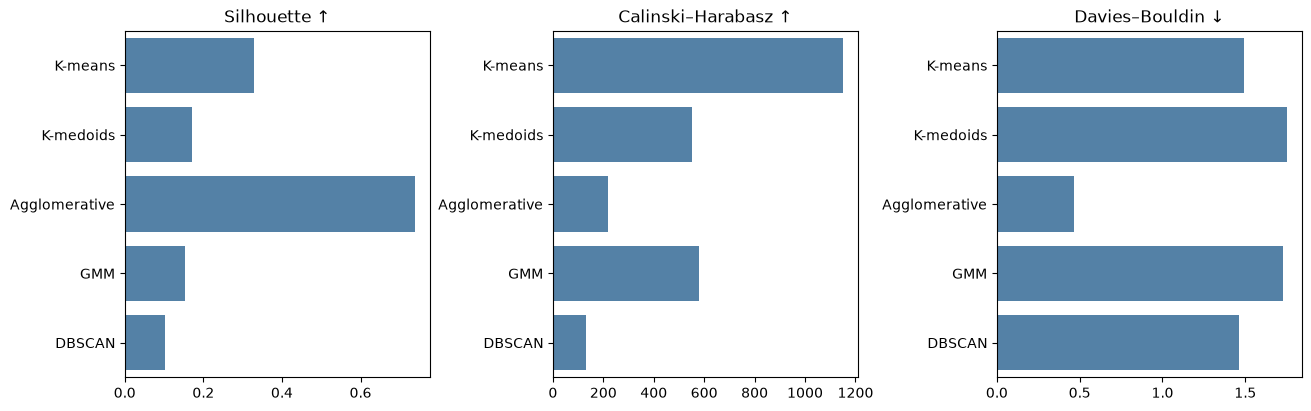

In [41]:
comparison = pd.DataFrame(results_rows)
comparison["Eligible"] = comparison["Clusters"].ge(2) & comparison["Silhouette"].notna()
mask = comparison["Model"].eq("DBSCAN")
comparison.loc[mask, "Eligible"] &= comparison.loc[mask, "Coverage_pct"].ge(80) & comparison.loc[mask, "Min_size"].ge(20)
mask = comparison["Model"].eq("GMM")
comparison.loc[mask, "Eligible"] &= comparison.loc[mask, "Converged"].eq(True)

model_order = ["K-means", "K-medoids", "Agglomerative", "GMM", "DBSCAN"]
comparison["Model"] = pd.Categorical(comparison["Model"], categories=model_order, ordered=True)
comparison["Stage"] = pd.Categorical(comparison["Stage"], categories=["Baseline", "Tuned", "Calibration"], ordered=True)
comparison["Calibration"] = pd.Categorical(comparison["Calibration"], categories=["Standard", "PCA95", "Robust"], ordered=True)
comparison = comparison.sort_values(["Model", "Stage", "Calibration"]).reset_index(drop=True)
comparison.to_csv(CLUSTERING_DIR / "model_comparison.csv", index=False)
pd.DataFrame(tuning_rows).to_csv(CLUSTERING_DIR / "all_tuning_trials.csv", index=False)
assignments = {f"{name} / Baseline": labels for name, labels in baseline_labels.items()}
assignments.update({f"{name} / Tuned": labels for name, labels in tuned_labels.items()})
assignments.update(calibration_labels)
pd.DataFrame(assignments, index=df_transformed.index).to_csv(CLUSTERING_DIR / "all_model_assignments.csv")

tuned_comparison = comparison.loc[(comparison["Stage"] == "Tuned") & (comparison["Calibration"] == "Standard")]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), layout="constrained")
for ax, metric, title in zip(axes, ["Silhouette", "Calinski_Harabasz", "Davies_Bouldin"],
                            ["Silhouette ↑", "Calinski–Harabasz ↑", "Davies–Bouldin ↓"]):
    sns.barplot(data=tuned_comparison, x=metric, y="Model", color="steelblue", ax=ax)
    ax.set(title=title, xlabel="", ylabel="")
fig.savefig(CLUSTERING_DIR / "tuned_model_scores.png", dpi=160, bbox_inches="tight")
plt.show()


In [42]:
# Model-specific objectives: compare within a model and the same calibration.
native_columns = ["Model", "Stage", "Calibration", "Inertia", "Sum_distances", "AIC", "BIC", "Converged"]
display(comparison[native_columns].dropna(subset=["Inertia", "Sum_distances", "BIC"], how="all").round(3))
print("Selected standard configurations:")
display(tuned_comparison[["Model", "Parameters"]])

full_coverage = comparison.loc[comparison["Coverage_pct"].eq(100) & comparison["Silhouette"].notna()]
leader = full_coverage.sort_values("Silhouette", ascending=False).iloc[0]
print(f"Highest full-coverage silhouette: {leader['Model']} / {leader['Stage']} / {leader['Calibration']}: "
      f"{leader['Silhouette']:.3f}. Smallest cluster: {int(leader['Min_size'])} observations; "
      f"largest cluster: {leader['Largest_cluster_pct']:.2f}% of observations.")


Selected standard configurations:
Highest full-coverage silhouette: Agglomerative / Tuned / Standard: 0.739. Smallest cluster: 9 observations; largest cluster: 99.76% of observations.


,Model,Stage,Calibration,Inertia,Sum_distances,AIC,BIC,Converged
0,K-means,Baseline,Standard,42311.690,NaN,NaN,NaN,NaN
1,K-means,Tuned,Standard,48577.000,NaN,NaN,NaN,NaN
2,K-means,Calibration,PCA95,45847.516,NaN,NaN,NaN,NaN
3,K-means,Calibration,Robust,37551.096,NaN,NaN,NaN,NaN
4,K-medoids,Baseline,Standard,NaN,12198.853,NaN,NaN,NaN
5,K-medoids,Tuned,Standard,NaN,10090.657,NaN,NaN,NaN
6,K-medoids,Calibration,PCA95,NaN,9458.696,NaN,NaN,NaN
7,K-medoids,Calibration,Robust,NaN,8882.625,NaN,NaN,NaN
12,GMM,Baseline,Standard,NaN,NaN,84793.057,87644.706,True
13,GMM,Tuned,Standard,NaN,NaN,52877.135,60491.907,True


,Model,Parameters
1,K-means,"{'n_clusters': 2, 'random_state': 1, 'n_init':..."
5,K-medoids,"{'n_clusters': 8, 'method': 'fasterpam', 'init..."
9,Agglomerative,"{'n_clusters': 2, 'metric': 'euclidean', 'link..."
13,GMM,"{'n_components': 8, 'covariance_type': 'full',..."
17,DBSCAN,"{'eps': 2.2084915719010025, 'min_samples': 20,..."


In [43]:
final_columns = ["Clusters", "Silhouette", "Calinski_Harabasz", "Davies_Bouldin",
                 "Coverage_pct", "Noise_rows", "Min_size", "Largest_cluster_pct",
                 "Fit_seconds", "Seed_stability_ARI", "ARI_vs_standard", "Shared_assigned_pct", "Eligible"]
final_table = comparison.set_index(["Model", "Stage", "Calibration"])[final_columns]
display(final_table.style.format({"Clusters": "{:.0f}", "Noise_rows": "{:.0f}", "Min_size": "{:.0f}",
                 "Coverage_pct": "{:.1f}", "Largest_cluster_pct": "{:.1f}"}, precision=4, na_rep="—")
        .set_caption("All models: baselines, tuning and calibrations — scores in the original 17-feature space"))
